# Problem Statement

The goal of this hackathon is to build an accurate and generalizable machine learning model that can predict the coefficient of thermal expansion (CTE) of inorganic compounds based on their chemical composition.
Accurate prediction of CTE is essential for designing materials that maintain dimensional stability under temperature changes — a critical property for ceramics, oxides, and functional materials used in high-temperature or thermal-cycling environments.

Participants are provided with a preprocessed and featurized dataset, where each compound’s chemical composition has already been transformed into a large set of numerical descriptors that capture underlying physical and chemical trends.
Your task is to train and validate predictive models using this dataset and explore strategies to improve prediction accuracy and robustness.

## What Has Already Been Done

A complete data preparation and feature engineering pipeline has been built and executed in advance. The dataset you will receive has already gone through the following stages:

1. Data Collection and Cleaning

The original dataset contained chemical compositions and measured CTE values for a wide range of oxide materials.

Each composition was cleaned (removal of text annotations, spaces, parentheses) and normalized (e.g., “La.4Sr.6TiO3” → “La0.4Sr0.6TiO3”) to ensure consistent parsing.

2. Feature Engineering

Three main classes of features have been computed using domain-informed and data-driven methods:

Ionic Statistics

Average ionic radius

Ionic size mismatch percentage

Atomic mass difference between constituent cations
These features capture how atomic-scale size and mass disparities influence thermal expansion behavior.

Polyhedral Descriptors

Each formula was heuristically classified into a common oxide structural prototype (e.g., perovskite, spinel, pyrochlore, garnet).

Site occupancy (“A-site”, “B-site”, etc.) and coordination preferences (tetrahedral, octahedral, multi-coordinated) were assigned to each element.

The resulting descriptors encode local geometry and oxidation states, which strongly affect lattice expansion.

Magpie Composition Features

Standardized matminer features based on elemental properties (mean, variance, range of electronegativity, atomic volume, valence electron count, etc.).

These provide a general chemical representation that complements domain heuristics.

All of these were merged into a final feature matrix — a single dataset where each row corresponds to a compound and each column represents a quantitative descriptor.

3. Baseline Modeling and Deployment Pipeline

Three baseline regression models were trained:

Linear Regression

Random Forest

Kernel Ridge Regression

Each was wrapped in a consistent preprocessing pipeline with median imputation and feature scaling.

Models were evaluated using R², MAE, and RMSE, and the best-performing model was refit on the entire dataset.

The best model and feature column list were saved as deployable artifacts (cte_best_pipeline.joblib and cte_training_feature_columns.csv).

A prediction helper was built to process new formulas — converting raw chemical strings into features and predicting CTE using the trained model.

## What Participants Need to Do

Your role as a participant is to develop and improve predictive models for CTE using the provided featurized dataset.
You can approach this as both a modeling and scientific reasoning challenge.

Required Objective:

Use the provided feature matrix (which includes CTE as the target) to train and validate an ML model that accurately predicts CTE for unseen materials.

Evaluate model performance using regression metrics such as R², MAE, and RMSE.

Suggested Approaches:

You are encouraged to explore, experiment, and justify your modeling choices. For example:

Implement cross-validation (K-fold or GroupKFold) to assess generalization.

Tune hyperparameters for the baselines or introduce advanced models:

Gradient Boosting (XGBoost, LightGBM, CatBoost)

Support Vector Regression (SVR)

Neural networks (e.g., MLPRegressor)

Perform feature selection or dimensionality reduction (e.g., PCA, mutual information, SHAP importance).

Investigate feature importance and interpretability — which physical or chemical features drive CTE behavior?

Test robustness by predicting on the provided list of unknown compositions and analyzing whether results make physical sense (e.g., RE pyrochlores having low-to-moderate CTE).

Deliverables:

At minimum, participants should provide:

A trained ML model or pipeline script (Colab/Jupyter notebook).

Evaluation metrics on the test or validation split.

(Optional) Predictions for the unknown compositions supplied.

A short explanation of the model choice, key features, and rationale.

## Installs

In [1]:
!pip install ace-tools

In [2]:
!pip install pymatgen matminer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.1/809.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.1/753.1 kB 23.2 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.3-py3-none-any.whl size=4354

In [3]:
!pip install pandas openpyxl pymatgen

In [4]:
!pip install shap scikit-learn matplotlib seaborn pandas

## Data Upload and Featurization

Here you will need to upload the dataset file "CTE Values 2.xlsx"

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/KalininGroup/camm_hackathon/k4my4r/docs/day_3_10242025/CTE%20Values%202.xlsx"
# If openpyxl isn't available in your runtime, run: !pip install openpyxl
df = pd.read_excel(url)  # pandas will infer engine=openpyxl
df.head()

,Composition,CTE Value
0,Y0.5Yb0.5Ta0.5Nb0.5ZrO7,0.000011
1,Y0.4175Yb0.4175Ta0.4175Nb0.4175ZrO6.67,0.000011
2,Al2O3Y0.6Er0.6Yb0.6Ho0.6Lu0.6Al5O12,0.000008
3,Al2O3Y3Al5O12,0.000008
4,La0.4Nd0.4Sm0.4Eu0.4Gd0.4Zr2O7,0.000013


In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
from pymatgen.core.composition import Composition
from pymatgen.core.periodic_table import Element

# ---------------- CONFIG ----------------
IN_XLSX  = url #"CTE Values 2.xlsx"      # must have column 'Composition'
OUT_XLSX = "CTE_with_Ionic_Stats_FINAL.xlsx"
OUT_POLY = "poly_descriptor_matrix.csv"
OUT_FEAT = "feature_matrix.csv"      # ionic stats + polyhedra only (no labels)

# ---------------- IONIC STATS (your function, slightly hardened) ----------------
def compute_ionic_stats(formula):
    try:
        comp = Composition(formula)
        elements = comp.elements
        fractions = [comp.get_atomic_fraction(el) for el in elements]

        ionic_radii = []
        atomic_masses = []
        symbols = []

        for el in elements:
            # Choose a plausible oxidation state if available
            ox_states = el.common_oxidation_states
            ox_state = ox_states[0] if ox_states else None
            # Ionic radius lookup (may be None)
            # Note: Element.ionic_radii is a mapping {oxidation:int -> radius}
            radius = None
            if ox_state is not None and hasattr(el, "ionic_radii") and el.ionic_radii:
                radius = el.ionic_radii.get(ox_state, None)

            ionic_radii.append(radius)
            atomic_masses.append(float(el.atomic_mass))
            symbols.append(el.symbol)

        # Filter to valid radii
        valid = [(r, f) for r, f in zip(ionic_radii, fractions) if r is not None]
        if not valid:
            return None, None, None

        radii, fracs = zip(*valid)
        avg_radius = sum(r * f for r, f in zip(radii, fracs))
        var_radius = sum(f * (r - avg_radius) ** 2 for r, f in zip(radii, fracs))
        std_radius = var_radius ** 0.5
        mismatch_pct = (std_radius / avg_radius) * 100 if avg_radius else None

        # Cation mass spread (exclude light anions/typical framework former if you want)
        EXCLUDED = {"O"}  # adjust if you want to exclude Al/Si/B as in your note
        cation_masses = [m for m, s in zip(atomic_masses, symbols) if s not in EXCLUDED]
        cation_fracs  = [f for s, f in zip(symbols, fractions) if s not in EXCLUDED]

        if not cation_masses or not cation_fracs:
            return round(avg_radius, 4), (None if mismatch_pct is None else round(mismatch_pct, 2)), None

        total_frac = sum(cation_fracs) or 1.0
        norm_fracs = [f / total_frac for f in cation_fracs]

        mean_mass = sum(m * f for m, f in zip(cation_masses, norm_fracs))
        min_mass = min(cation_masses)
        max_mass = max(cation_masses)
        mass_diff_pct = ((max_mass - min_mass) / mean_mass) * 100 if mean_mass else None

        return (
            None if avg_radius is None else round(avg_radius, 4),
            None if mismatch_pct is None else round(mismatch_pct, 2),
            None if mass_diff_pct is None else round(mass_diff_pct, 2),
        )

    except Exception as e:
        print(f"Error parsing {formula}: {e}")
        return None, None, None

# ---------------- POLYHEDRA DESCRIPTORS ----------------
# Heuristic site buckets (A/B/C) + oxidation-state tagging → {El{ox}_tet|oct|multi: count}
RARE_EARTHS = {"La","Ce","Pr","Nd","Pm","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb","Lu","Y","Sc"}
A_LIKE = RARE_EARTHS | {"Ba","Sr","Ca","K","Na","Pb","Bi"}
B_LIKE = {"Al","Ga","In","Fe","Co","Ni","Mn","Cr","V","Nb","Ta","Ti","Zr","Hf","Sn","Ge","Si","Mo","W","Cu","Mg","Zn"}

# Narrow set of common valences; add if you need more
COMMON_VALENCES = {
    "La":[3],"Ce":[3,4],"Pr":[3,4],"Nd":[3],"Sm":[3],"Eu":[2,3],"Gd":[3],"Tb":[3,4],"Dy":[3],"Ho":[3],
    "Er":[3],"Tm":[3],"Yb":[2,3],"Lu":[3],"Y":[3],"Sc":[3],
    "Ba":[2],"Sr":[2],"Ca":[2],"K":[1],"Na":[1],
    "Al":[3],"Ga":[3],"In":[3],"Fe":[2,3],"Co":[2,3],"Ni":[2,3],"Mn":[2,3,4],"Cr":[3],"V":[3,5],
    "Nb":[5],"Ta":[5],"Ti":[4,3],"Zr":[4],"Hf":[4],"Sn":[4,2],"Ge":[4],"Si":[4],
    "Mo":[6,5],"W":[6,5],"Cu":[1,2],"Mg":[2],"Zn":[2],
    "Pb":[2,4],"Bi":[3]
}

def _detect_proto(counts):
    nO = counts.get("O", 0.0)
    metals = {k:v for k,v in counts.items() if k != "O"}
    ncat = sum(metals.values())
    # Loose matching to common cubic families
    if nO > 0 and abs(nO - 12) <= 0.3 and abs(ncat - 8) <= 0.3:  return "GARNET_A3B2C3O12"
    if nO > 0 and abs(nO - 7)  <= 0.3 and abs(ncat - 4) <= 0.3:  return "PYRO_A2B2O7"
    if nO > 0 and abs(nO - 4)  <= 0.3 and abs(ncat - 3) <= 0.3:  return "SPINEL_AB2O4"
    if nO > 0 and abs(nO - 3)  <= 0.3 and abs(ncat - 2) <= 0.3:  return "PEROV_ABO3"
    return "GEN_OXIDE"

def _split_sites_garnet(metals):
    A, B, C = {}, {}, {}
    rest = metals.copy()
    cap = {"A":3.0, "B":2.0, "C":3.0}

    # Fill A (prefer A-like)
    for el in list(rest.keys()):
        if el in A_LIKE and cap["A"] > 0:
            take = min(rest[el], cap["A"])
            A[el] = A.get(el,0)+take; rest[el]-=take; cap["A"]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    # Now fill B, C (prefer B-like)
    for site, capacity in (("B", "B"), ("C", "C")):
        for el in list(rest.keys()):
            if el in B_LIKE and cap[site] > 0:
                take = min(rest[el], cap[site])
                (B if site=="B" else C)[el] = (B if site=="B" else C).get(el,0)+take
                rest[el]-=take; cap[site]-=take
                if rest[el] <= 1e-12: rest.pop(el, None)
    # Any leftovers: fill largest-first
    for site in ("A","B","C"):
        while cap[site] > 1e-12 and rest:
            el = max(rest.items(), key=lambda kv: kv[1])[0]
            take = min(rest[el], cap[site])
            if site=="A": A[el]=A.get(el,0)+take
            elif site=="B": B[el]=B.get(el,0)+take
            else: C[el]=C.get(el,0)+take
            rest[el]-=take; cap[site]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    return A, B, C

def _split_sites_binary(proto, metals):
    # For ABO3: caps (A=1, B=1). For spinel: (A=1, B=2). For pyrochlore: (A=2, B=2)
    caps = {"PEROV_ABO3": (1.0,1.0), "SPINEL_AB2O4": (1.0,2.0), "PYRO_A2B2O7": (2.0,2.0)}
    capA, capB = caps.get(proto, (1.0,1.0))
    A, B = {}, {}
    rest = metals.copy()

    for el in list(rest.keys()):
        if el in A_LIKE and capA > 0:
            take = min(rest[el], capA)
            A[el] = A.get(el,0)+take; rest[el]-=take; capA-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for el in list(rest.keys()):
        if el in B_LIKE and capB > 0:
            take = min(rest[el], capB)
            B[el] = B.get(el,0)+take; rest[el]-=take; capB-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    # fill leftovers greedily
    for el in list(rest.keys()):
        if capA > 0:
            take = min(rest[el], capA)
            A[el] = A.get(el,0)+take; rest[el]-=take; capA-=take
        if rest.get(el,0) > 0 and capB > 0:
            take = min(rest[el], capB)
            B[el] = B.get(el,0)+take; rest[el]-=take; capB-=take
        if rest.get(el,0) <= 1e-12: rest.pop(el, None)
    return A, B

def _guess_valences(metals, nO):
    # Try to match sum(valence_i * amount_i) = 2*nO (oxygen as -2)
    target = 2.0 * nO
    els = list(metals.keys())
    # Candidate lists
    cand = [COMMON_VALENCES.get(el, [3]) for el in els]
    best = None

    def backtrack(i, cur, assign):
        nonlocal best
        if best is not None:
            return
        if i == len(els):
            if abs(cur - target) < 1e-6:
                best = dict(assign)
            return
        el = els[i]; amt = metals[el]
        for v in cand[i][:3]:
            backtrack(i+1, cur + v*amt, {**assign, el: v})

    backtrack(0, 0.0, {})
    if best is None:
        # Fallback: RE=3+, others first listed; adjust last to hit target
        best = {el: (3 if el in RARE_EARTHS else cand[i][0]) for i, el in enumerate(els)}
        cur = sum(best[el]*metals[el] for el in els)
        if els and abs(target - cur) > 1e-9:
            last = els[-1]
            if metals[last] != 0:
                best[last] = best[last] + (target - cur) / metals[last]
    # Round to nearest int if close
    for k, v in list(best.items()):
        if np.isfinite(v):
            vi = int(round(v))
            best[k] = vi if abs(vi - v) < 0.25 else v
    return best

def _poly_rows_for_formula(formula):
    try:
        comp = Composition(formula).get_el_amt_dict()
    except Exception:
        return []

    if "O" not in comp:
        return []  # only oxide heuristics here
    nO = float(comp["O"])
    metals = {k: float(v) for k, v in comp.items() if k != "O" and v > 0}
    if not metals:
        return []

    proto = _detect_proto(comp)
    rows = []

    def emit(el, bucket, amt, ox=None):
        return {
            "Compound": formula,
            "Element": el,
            "CN_bucket": bucket,        # 'tet' | 'oct' | 'multi'
            "Count": float(amt),
            "Oxidation": None if ox is None else (int(ox) if float(ox).is_integer() else ox),
        }

    if proto == "GARNET_A3B2C3O12":
        A, B, C = _split_sites_garnet(metals)
        for el, amt in A.items(): rows.append(emit(el, "multi", amt))
        for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        for el, amt in C.items(): rows.append(emit(el, "tet",   amt))
    elif proto in ("PEROV_ABO3", "SPINEL_AB2O4", "PYRO_A2B2O7"):
        A, B = _split_sites_binary(proto, metals)
        if proto == "PEROV_ABO3":
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        elif proto == "SPINEL_AB2O4":
            for el, amt in A.items(): rows.append(emit(el, "tet",   amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        else:  # pyrochlore
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
    else:
        # Generic oxide fallback: count metals as octahedral
        for el, amt in metals.items():
            rows.append(emit(el, "oct", amt))

    # Add oxidation states by charge balance guess
    oxmap = _guess_valences(metals, nO)
    for r in rows:
        el = r["Element"]
        if el in oxmap and np.isfinite(oxmap[el]):
            oxv = oxmap[el]
            r["Oxidation"] = int(oxv) if float(oxv).is_integer() else oxv
    return rows

def _desc_name(el, bucket, ox):
    if ox is None or (isinstance(ox, float) and not np.isfinite(ox)):
        return f"{el}_{bucket}"
    try:
        oxi = int(round(float(ox)))
        return f"{el}{oxi}_{bucket}"
    except Exception:
        return f"{el}_{bucket}"

def build_polyhedra_descriptor_matrix(formulas):
    """Return (poly_wide_df, used_desc_cols)"""
    long_rows = []
    uniq = pd.unique(pd.Series(formulas).dropna())
    for f in uniq:
        long_rows.extend(_poly_rows_for_formula(str(f)))

    if not long_rows:
        return pd.DataFrame({"Compound": uniq}), []

    poly_long = pd.DataFrame(long_rows)
    poly_long["desc"] = poly_long.apply(
        lambda r: _desc_name(r["Element"], r["CN_bucket"], r["Oxidation"]), axis=1
    )

    poly_wide = (
        poly_long.pivot_table(index="Compound", columns="desc", values="Count",
                              aggfunc="sum", fill_value=0.0)
        .reset_index()
    )
    # Clean potential duplicate columns
    poly_wide = poly_wide.loc[:, ~poly_wide.columns.duplicated()].copy()
    desc_cols = [c for c in poly_wide.columns if c != "Compound"]
    return poly_wide, desc_cols

# ---------------- MAIN ----------------
df = pd.read_excel(IN_XLSX)
if "Composition" not in df.columns:
    raise ValueError("Input file must contain a 'Composition' column.")

# Ionic stats
ion_stats = df["Composition"].apply(compute_ionic_stats).apply(pd.Series)
ion_stats.columns = ["Avg Ionic Radius (Å)", "Ionic Size Mismatch (%)", "Atomic Mass Diff (%)"]

# Polyhedra descriptors
poly_wide, desc_cols = build_polyhedra_descriptor_matrix(df["Composition"])
# Save standalone matrix (one row per unique composition)
poly_wide.to_csv(OUT_POLY, index=False)

# Merge descriptors back to the main dataframe
df_merged = df.copy()
df_merged = df_merged.merge(poly_wide, left_on="Composition", right_on="Compound", how="left")
if "Compound" in df_merged.columns:
    df_merged = df_merged.drop(columns=["Compound"])

# Attach ionic stats
for col in ion_stats.columns:
    df_merged[col] = ion_stats[col].values

# Save combined Excel
df_merged.to_excel(OUT_XLSX, index=False)

# Optional: save a pure-feature matrix (drop obvious non-features if present)
non_feature_cols = {"Composition", "a_A", "Lattice_A", "T_K", "Temperature", "Target", "Label"}
feat_cols = [c for c in df_merged.columns if c not in non_feature_cols]
pd.DataFrame(df_merged[feat_cols]).to_csv(OUT_FEAT, index=False)

print("✅ Wrote:")
print(f"- {OUT_XLSX}  (original sheet + ionic stats + polyhedra features)")
print(f"- {OUT_POLY}   (standalone polyhedra descriptor matrix)")
print(f"- {OUT_FEAT}   (feature-only CSV)")


✅ Wrote:
- CTE_with_Ionic_Stats_FINAL.xlsx  (original sheet + ionic stats + polyhedra features)
- poly_descriptor_matrix.csv   (standalone polyhedra descriptor matrix)
- feature_matrix.csv   (feature-only CSV)


In [7]:
import pandas as pd

# Load the Excel file (make sure this file is in the same folder as your notebook)
file_path = "CTE_with_Ionic_Stats_FINAL.xlsx"
df = pd.read_excel(file_path)

# Fill all NaN values with 0
df_filled = df.fillna(0)

# Preview the cleaned DataFrame
print(df_filled.head())

# Optional: Save to a new Excel file
df_filled.to_excel("Database_CTE_Focus_Cleaned.xlsx", index=False)

                              Composition  CTE Value  Al3_oct  Al3_tet  \
0                 Y0.5Yb0.5Ta0.5Nb0.5ZrO7   0.000011      0.0      0.0   
1  Y0.4175Yb0.4175Ta0.4175Nb0.4175ZrO6.67   0.000011      0.0      0.0   
2     Al2O3Y0.6Er0.6Yb0.6Ho0.6Lu0.6Al5O12   0.000008      7.0      0.0   
3                           Al2O3Y3Al5O12   0.000008      7.0      0.0   
4          La0.4Nd0.4Sm0.4Eu0.4Gd0.4Zr2O7   0.000013      0.0      0.0   

   Ba2_oct  Be3_oct  Ca2_multi  Ca2_oct  Ce-22_oct  Ce3_multi  ...  Yb2_oct  \
0      0.0      0.0        0.0      0.0        0.0        0.0  ...      0.0   
1      0.0      0.0        0.0      0.0        0.0        0.0  ...      0.0   
2      0.0      0.0        0.0      0.0        0.0        0.0  ...      0.0   
3      0.0      0.0        0.0      0.0        0.0        0.0  ...      0.0   
4      0.0      0.0        0.0      0.0        0.0        0.0  ...      0.0   

   Yb3_multi  Yb3_oct  Zr4_multi  Zr4_oct  Zr6_oct  Zr7_oct  \
0        0.0   0.

In [8]:
import pandas as pd
import re
from pymatgen.core.composition import Composition

def clean_formula(formula):
    return re.sub(r"\s*\(.*?\)", "", formula)

def extract_parentheses_substrings(s):
    return re.findall(r'\((.*?)\)', s)

def compstr_to_fractional(compstr, decimals=4):
    comp = Composition(compstr)
    return ''.join(f"{el.symbol}{round(comp.get_atomic_fraction(el), decimals)}" for el in comp.elements)

def normalize_composition(compstr, decimals=4):
    compstr = clean_formula(compstr)
    matches = extract_parentheses_substrings(compstr)
    for sub in matches:
        try:
            normalized = compstr_to_fractional(sub, decimals)
            compstr = compstr.replace(f"({sub})", normalized)
        except:
            pass
    try:
        return compstr_to_fractional(compstr, decimals)
    except:
        return "Invalid"

def get_pretty_formula(compstr, multiplier=100):
    try:
        comp = Composition(compstr)
        comp_dict = {el.symbol: int(comp.get_atomic_fraction(el) * multiplier) for el in comp.elements}
        return Composition(comp_dict).reduced_formula
    except:
        return "Invalid"

def batch_process(comp_series):
    results = []
    for raw in comp_series:
        cleaned = clean_formula(raw)
        norm = normalize_composition(cleaned)
        pretty = get_pretty_formula(norm)
        results.append({
            "Composition": raw,
            "Composition_clean": cleaned,
            "normalized": norm,
            "pretty_formula": pretty
        })
    return pd.DataFrame(results)

# Load the full dataset
df = pd.read_excel("Database_CTE_Focus_Cleaned.xlsx")

# Process only rows with valid Composition
composition_series = df["Composition"].dropna()
processed_df = batch_process(composition_series)

# Merge results back to original dataframe
final_df = df.merge(processed_df, on="Composition", how="left")

# Save the final dataframe
final_df.to_csv("normalized_compositions_output.csv", index=False)


In [9]:
import pandas as pd
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty

# Load your CSV with a column of normalized formulas
df = pd.read_csv("normalized_compositions_output.csv")  # or your custom path

# Filter out rows with "Invalid" compositions
df_valid = df[df["normalized"] != "Invalid"].copy()

# Create a Composition object column using the 'normalized' column
df_valid["composition_obj"] = df_valid["normalized"].apply(lambda x: Composition(x))

# Initialize featurizer
featurizer = ElementProperty.from_preset("magpie")

# Apply featurizer, ignoring errors for unrecognized elements
features_df = featurizer.featurize_dataframe(df_valid, "composition_obj", ignore_errors=True)

# Drop intermediate object column
features_df = features_df.drop(columns=["composition_obj"])

# Preview the result
display(features_df.head())

# Save the extracted features to CSV
features_df.to_csv("composition_features_pymatgen.csv", index=False)

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/118 [00:00<?, ?it/s]

,Composition,CTE Value,Al3_oct,Al3_tet,Ba2_oct,Be3_oct,Ca2_multi,Ca2_oct,Ce-22_oct,Ce3_multi,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,Y0.5Yb0.5Ta0.5Nb0.5ZrO7,0.000011,0.0,0,0,0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.0,12.0,229.0,217.0,71.650000,83.510000,12.0
1,Y0.4175Yb0.4175Ta0.4175Nb0.4175ZrO6.67,0.000011,0.0,0,0,0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.0,12.0,229.0,217.0,68.548500,80.762568,12.0
2,Al2O3Y0.6Er0.6Yb0.6Ho0.6Lu0.6Al5O12,0.000008,7.0,0,0,0,0.0,0.0,0,0.0,...,0.002247,0.000054,0.000105,0.0,12.0,225.0,213.0,94.224000,98.668800,12.0
3,Al2O3Y3Al5O12,0.000008,7.0,0,0,0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.0,12.0,225.0,213.0,93.480000,97.776000,12.0
4,La0.4Nd0.4Sm0.4Eu0.4Gd0.4Zr2O7,0.000013,0.0,0,0,0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.0,12.0,229.0,217.0,78.453109,84.564605,12.0


## Model Training and SHAP Analysis

You're final dataset for model training will be the file "composition_features_pymatgen.csv"

Shape of X after dropping columns: (118, 209)
Shape of X after dropping NaNs: (118, 209)

RandomForest:
y_test sample: [ 1.120e-05 -5.500e-07  1.304e-05  9.000e-06  6.600e-06]
y_pred sample: [1.11819095e-05 4.46000000e-07 1.11164417e-05 1.13753000e-05
 7.15000000e-06]
R² = 0.927, RMSE = 1.310521e-06, MSE = 1.717465e-12

GradientBoosting:
y_test sample: [ 1.120e-05 -5.500e-07  1.304e-05  9.000e-06  6.600e-06]
y_pred sample: [ 1.11651000e-05 -2.82922690e-07  1.07661086e-05  1.19816620e-05
  6.89287113e-06]
R² = 0.937, RMSE = 1.221176e-06, MSE = 1.491271e-12

SVR:
y_test sample: [ 1.120e-05 -5.500e-07  1.304e-05  9.000e-06  6.600e-06]
y_pred sample: [1.02400761e-05 7.20018378e-06 1.00447265e-05 8.88907893e-06
 9.75968436e-06]
R² = 0.254, RMSE = 4.188893e-06, MSE = 1.754683e-11

KNN:
y_test sample: [ 1.120e-05 -5.500e-07  1.304e-05  9.000e-06  6.600e-06]
y_pred sample: [1.1148e-05 1.9600e-07 1.0824e-05 1.0876e-05 8.2400e-06]
R² = 0.897, RMSE = 1.555109e-06, MSE = 2.418363e-12

XGBoost:
y_t

/tmp/ipython-input-2648981323.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)
/tmp/ipython-input-2648981323.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)
/tmp/ipython-input-2648981323.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)


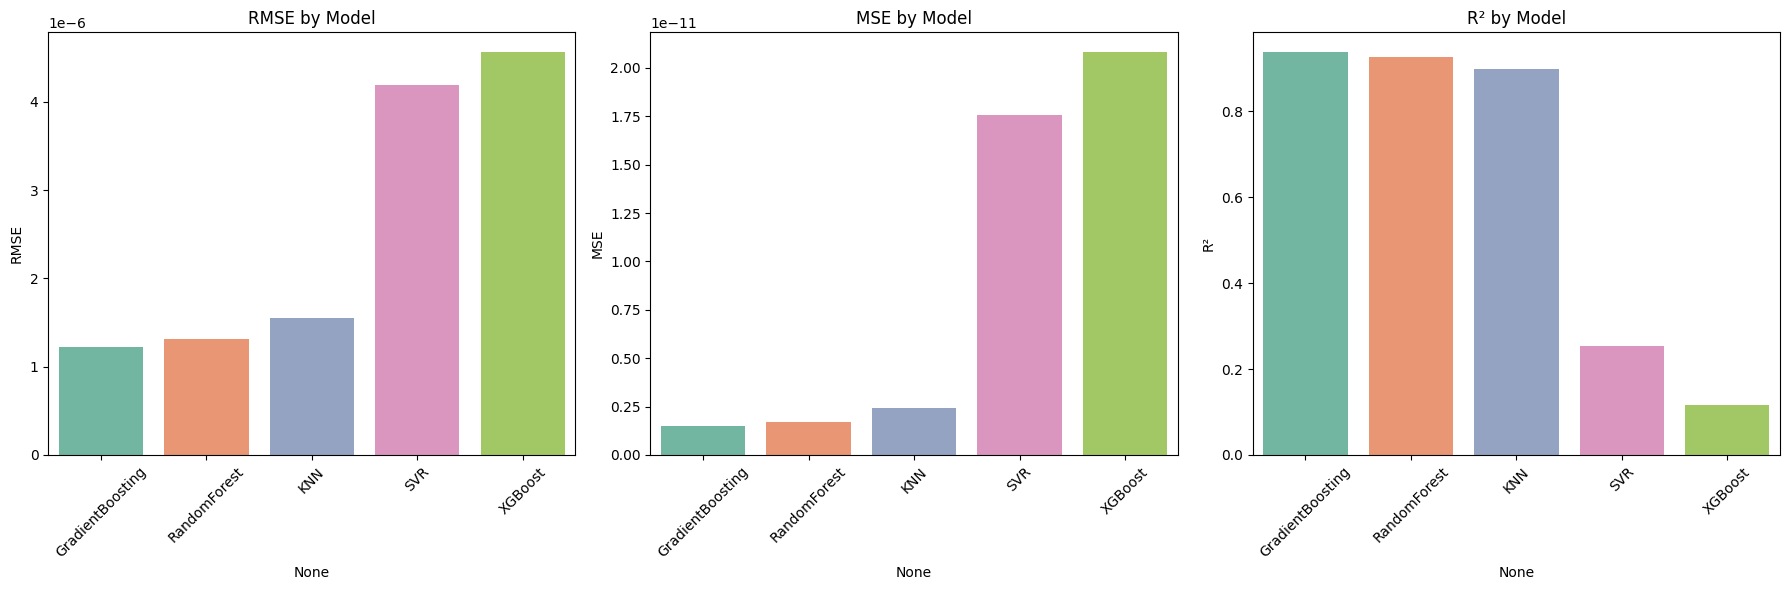

In [10]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Optional: XGBoost
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False

# Load and clean data
df = pd.read_csv("composition_features_pymatgen.csv") # Load the featurized data
drop_cols = ["Composition", "Composition_clean", "input", "normalized", "pretty_formula", 'Unnamed: 0']
# Filter out columns that exist in the DataFrame before dropping
cols_to_drop = [col for col in drop_cols if col in df.columns]

# Separate target variable before dropping columns
target_column = "CTE Value"
if target_column in df.columns:
    y = df[target_column]
    # Drop the target column from the feature set
    X = df.drop(columns=[target_column] + cols_to_drop, errors='ignore')
else:
    raise ValueError(f"Target column '{target_column}' not found in the DataFrame.")

# Ensure only numeric columns are used for features and drop rows with NaNs
X = X.select_dtypes(include=np.number)

# Print shape after dropping columns to diagnose
print("Shape of X after dropping columns:", X.shape)

X = X.dropna()
y = y.loc[X.index] # Align target variable with the cleaned feature set

# Print shape after dropping NaNs to diagnose
print("Shape of X after dropping NaNs:", X.shape)


# Normalize the target variable
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

# Models
models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=0),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=0),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}
if xgb_available:
    models["XGBoost"] = XGBRegressor(n_estimators=100, random_state=0)

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(y_pred, "flatten"):
        y_pred = y_pred.flatten()

    # Inverse transform predictions and actuals to original scale
    y_pred_orig = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_orig = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # Compute metrics in original units
    mse = np.mean((y_test_orig - y_pred_orig) ** 2)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_orig, y_pred_orig)

    results[name] = {
        "model": model, "MSE": mse, "RMSE": rmse, "R²": r2
    }

    print(f"\n{name}:")
    print(f"y_test sample: {y_test_orig[:5]}")
    print(f"y_pred sample: {y_pred_orig[:5]}")
    print(f"R² = {r2:.3f}, RMSE = {rmse:.6e}, MSE = {mse:.6e}")

# Summary DataFrame
metrics_df = pd.DataFrame(results).T[["MSE", "RMSE", "R²"]].sort_values("R²", ascending=False)

# Unique colors per model
palette = sns.color_palette("Set2", len(metrics_df))
color_dict = dict(zip(metrics_df.index, palette))

# Plot
plt.figure(figsize=(18, 6))
for i, metric in enumerate(["RMSE", "MSE", "R²"]):
    plt.subplot(1, 3, i + 1)
    sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)
    plt.title(f"{metric} by Model")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


=== SHAP Summary for Gradient Boosting Regressor ===


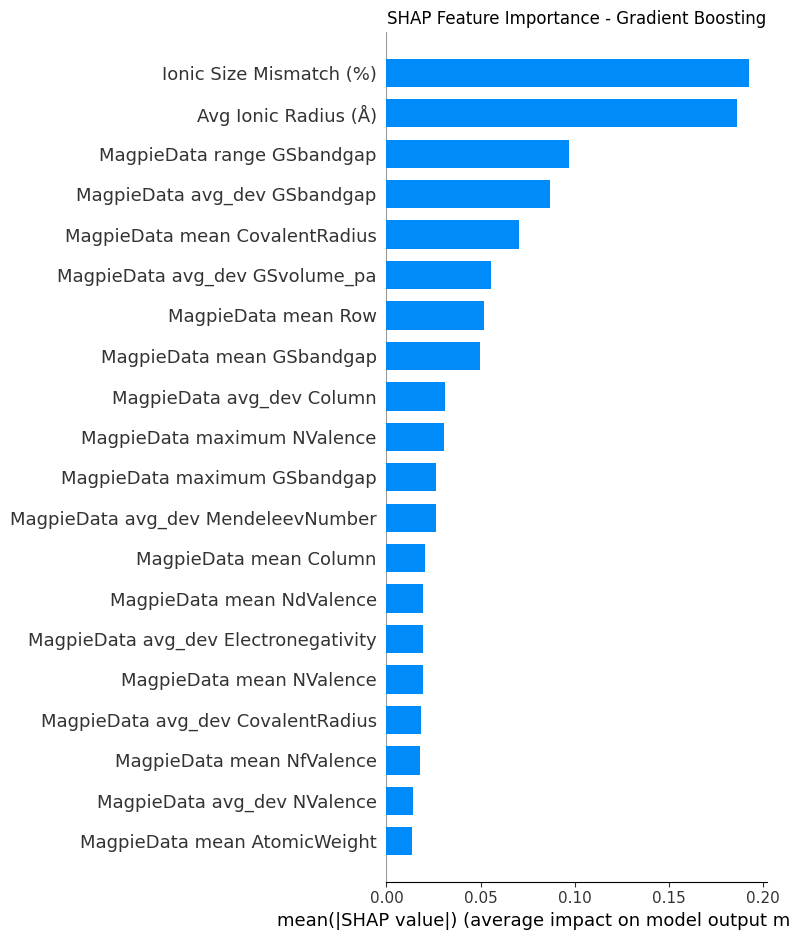

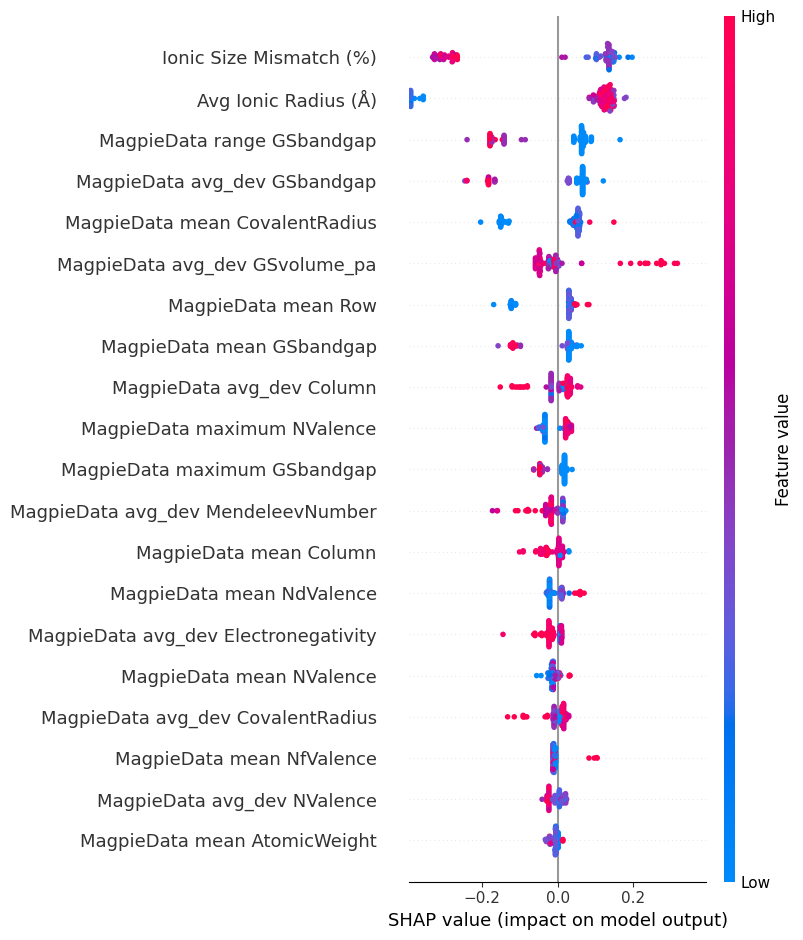

In [11]:
from sklearn.ensemble import GradientBoostingRegressor
import shap
import matplotlib.pyplot as plt
import numpy as np

# === Force use of Gradient Boosting Regressor ===
best_model_name = "GradientBoosting"
best_model = results[best_model_name]["model"]

print(f"\n=== SHAP Summary for Gradient Boosting Regressor ===")

# Confirm it's a tree-based model
if isinstance(best_model, GradientBoostingRegressor):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X)

    # Bar plot
    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance - Gradient Boosting")
    plt.tight_layout()
    plt.show()

    # Beeswarm plot
    plt.xlim(-.5 * np.max(np.abs(shap_values)), .5 * np.max(np.abs(shap_values)))  # 150% of max abs value
    shap.summary_plot(shap_values, X, plot_type="dot")
else:
    print("The selected model is not a GradientBoostingRegressor.")


## CTE Predictions

In [12]:
import pandas as pd
import numpy as np
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty



# --- [1] Your pre-trained objects (already defined in notebook) ---
# best_model       : The Bayesian-optimized GradientBoostingRegressor
# y_scaler         : The StandardScaler used for the target "CTE (K_1)"
# X                : Your training features dataframe (used to get correct columns)

# --- [2] New compositions to predict ---
new_formulas = [
    "Y3Al5O12",
    "Ce3Al5O12",
    "La3Al5O12",
    "Y3Al5O12",
    "Dy2Yb2Nb2Ta2Ce2O7",
    "(Y1.125Nd.125Sm.125Eu.125Dy.125Ho.125Er.125Yb.125)3Al5O12",
    "(Y.5Yb.5)3Al5O12"
]

# --- [3] Featurize new compositions ---
# Convert formulas to pymatgen Composition objects
comp_objs = []
for f in new_formulas:
    try:
        comp_objs.append(Composition(f))
    except Exception as e:
        print(f"Could not parse formula {f}: {e}")
        comp_objs.append(None)

# Filter out invalid compositions before featurizing
valid_comp_objs = [c for c in comp_objs if c is not None]
valid_formulas = [f for f, c in zip(new_formulas, comp_objs) if c is not None]

feature_df = pd.DataFrame({"composition_obj": valid_comp_objs})

# Use the same featurizer as training
featurizer = ElementProperty.from_preset("magpie")
feature_df = featurizer.featurize_dataframe(feature_df, "composition_obj")

# Print featurized dataframe to diagnose
print("Featurized DataFrame for new compositions:")
pd.options.display.float_format = '{:.8f}'.format  # Show more precision when printing
display(feature_df)

# --- [4] Align columns with training data ---
# Add missing columns with 0.0 and reindex to match training columns
X_new = feature_df.reindex(columns=X.columns, fill_value=0.000)

# --- [5] Predict using optimized model ---
y_pred_scaled = best_model.predict(X_new)
y_pred_cte = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# --- [6] Output predictions with more decimal precision ---
pred_df = pd.DataFrame({
    "Composition": valid_formulas,
    "Predicted CTE (K⁻¹)": np.round(y_pred_cte, 8)
})

print("\nPredicted CTE values:")
print(pred_df)

# --- [7] Save to CSV with 8 decimal places ---
pred_df.to_csv("cte_predictions_gradient_boost.csv", index=False, float_format="%.8f")

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/7 [00:00<?, ?it/s]

Featurized DataFrame for new compositions:


,composition_obj,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,"(Y, Al, O)",8.00000000,39.00000000,31.00000000,13.90000000,7.53000000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
1,"(Ce, Al, O)",8.00000000,58.00000000,50.00000000,16.75000000,12.37500000,8.00000000,15.00000000,87.00000000,72.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
2,"(La, Al, O)",8.00000000,57.00000000,49.00000000,16.60000000,12.12000000,8.00000000,13.00000000,87.00000000,74.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
3,"(Y, Al, O)",8.00000000,39.00000000,31.00000000,13.90000000,7.53000000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
4,"(Dy, Yb, Nb, Ta, Ce, O)",8.00000000,73.00000000,65.00000000,39.52941176,25.96539792,8.00000000,15.00000000,87.00000000,72.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,229.00000000,217.00000000,130.94117647,97.95155709,12.00000000
5,"(Y, Nd, Sm, Eu, Dy, Ho, Er, Yb, Al, O)",8.00000000,70.00000000,62.00000000,20.15760870,15.79820416,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,229.00000000,217.00000000,106.40217391,98.50661626,12.00000000
6,"(Y, Yb, Al, O)",8.00000000,70.00000000,62.00000000,16.22500000,11.48250000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,94.87500000,99.45000000,12.00000000



Predicted CTE values:
                                         Composition  Predicted CTE (K⁻¹)
0                                           Y3Al5O12           0.00000674
1                                          Ce3Al5O12           0.00000738
2                                          La3Al5O12           0.00000738
3                                           Y3Al5O12           0.00000674
4                                  Dy2Yb2Nb2Ta2Ce2O7           0.00000626
5  (Y1.125Nd.125Sm.125Eu.125Dy.125Ho.125Er.125Yb....           0.00000660
6                                   (Y.5Yb.5)3Al5O12           0.00000721


In [13]:
import pandas as pd
import numpy as np
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty

# --- [1] Your pre-trained objects (already defined in notebook) ---
# best_model       : The Bayesian-optimized GradientBoostingRegressor
# y_scaler         : The StandardScaler used for the target "CTE (K_1)"
# X                : Your training features dataframe (used to get correct columns)

# --- [2] New compositions to predict ---
new_formulas = [
    "Y3Al5O12",
    "Y1.5Dy1.5Al5O12",
    "Y.9999Dy.9999Ho.9999Al5O12",
    "Y.75Dy.75Ho.75Er.75Al5O12",
    "Y.6La.6Dy.6Ho.6Er.6Al5O12",
    "Y.60Nd.60Dy.60Ho.60Er.6Al5O12",
    "(Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.1666)3Al5O12",
    "(Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285Ho0.14285Er0.14285)3Al5O12 ",
    "Y3Fe5O12",
    "Y3Fe2.50Al2.50O12",
    "Y3Fe2.475Al2.475Mn0.05O12",
    "Y3Fe2.475Al2.475Co0.05O12",
    "Y3Fe2.475Al2.475Ni0.05O12",
    "Y3Fe2.475Al2.475Cu0.05O12",
    "Y3Fe2.45Al2.45Mn0.025Co0.025Ni0.025Cu0.025O12",
    "Y.6Eu.6Dy.6Ho.6Er.6Al5O12",
    "La.666Gd.666Lu.666TiZrO7",
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7",
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7",
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7",
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7",
    "Eu.5Gd.5Ho.5Er.5Ti2O7",
    "GdHoTi2O7",
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7"
]

# --- [3] Featurize new compositions ---
# Convert formulas to pymatgen Composition objects
comp_objs = []
for f in new_formulas:
    try:
        comp_objs.append(Composition(f))
    except Exception as e:
        print(f"Could not parse formula {f}: {e}")
        comp_objs.append(None)

# Filter out invalid compositions before featurizing
valid_comp_objs = [c for c in comp_objs if c is not None]
valid_formulas = [f for f, c in zip(new_formulas, comp_objs) if c is not None]

feature_df = pd.DataFrame({"composition_obj": valid_comp_objs})

# Use the same featurizer as training
featurizer = ElementProperty.from_preset("magpie")
feature_df = featurizer.featurize_dataframe(feature_df, "composition_obj")

# Print featurized dataframe to diagnose
print("Featurized DataFrame for new compositions:")
display(feature_df)

# --- [4] Align columns with training data ---
# Add missing columns with 0.0 and reindex to match training columns
X_new = feature_df.reindex(columns = X.columns, fill_value=0.000)

# --- [5] Predict using optimized model ---
y_pred_scaled = best_model.predict(X_new)
y_pred_cte = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# --- [6] Output predictions ---
pred_df = pd.DataFrame({
    "Composition": valid_formulas,
    "Predicted CTE (K⁻¹)": y_pred_cte
})
print(pred_df)

# --- [7] Save to CSV ---
pred_df.to_csv("cte_predictions_gradient_boost.csv", index=False)

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/24 [00:00<?, ?it/s]

Featurized DataFrame for new compositions:


,composition_obj,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,"(Y, Al, O)",8.00000000,39.00000000,31.00000000,13.90000000,7.53000000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
1,"(Y, Dy, Al, O)",8.00000000,66.00000000,58.00000000,15.92500000,10.97250000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
2,"(Y, Dy, Ho, Al, O)",8.00000000,67.00000000,59.00000000,16.64938974,12.20414562,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.54847823,96.65962377,12.00000000
3,"(Y, Dy, Ho, Er, Al, O)",8.00000000,68.00000000,60.00000000,17.05000000,12.88500000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
4,"(Y, La, Dy, Ho, Er, Al, O)",8.00000000,68.00000000,60.00000000,16.96000000,12.73200000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
5,"(Y, Nd, Dy, Ho, Er, Al, O)",8.00000000,68.00000000,60.00000000,17.05000000,12.88500000,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,92.55000000,96.66000000,12.00000000
6,"(Y, Nd, Sm, Dy, Ho, Er, Al, O)",8.00000000,68.00000000,60.00000000,17.09740584,12.96636792,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,91.84415065,95.81872990,12.00000000
7,"(Y, Nd, Sm, Eu, Dy, Ho, Er, Al, O)",8.00000000,68.00000000,60.00000000,17.15681618,13.06668550,8.00000000,12.00000000,87.00000000,75.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,229.00000000,217.00000000,92.69923274,96.83980559,12.00000000
8,"(Y, Fe, O)",8.00000000,39.00000000,31.00000000,17.15000000,10.98000000,8.00000000,12.00000000,87.00000000,75.00000000,...,2.11066280,0.52766570,0.79149855,0.00000000,12.00000000,229.00000000,217.00000000,93.55000000,97.86000000,12.00000000
9,"(Y, Fe, Al, O)",8.00000000,39.00000000,31.00000000,15.52500000,9.66125000,8.00000000,12.00000000,87.00000000,75.00000000,...,2.11066280,0.26383285,0.46170749,0.00000000,12.00000000,229.00000000,217.00000000,93.05000000,97.26000000,12.00000000


                                          Composition  Predicted CTE (K⁻¹)
0                                            Y3Al5O12           0.00000674
1                                     Y1.5Dy1.5Al5O12           0.00000682
2                          Y.9999Dy.9999Ho.9999Al5O12           0.00000744
3                           Y.75Dy.75Ho.75Er.75Al5O12           0.00000764
4                           Y.6La.6Dy.6Ho.6Er.6Al5O12           0.00000744
5                       Y.60Nd.60Dy.60Ho.60Er.6Al5O12           0.00000733
6   (Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.16...           0.00000778
7   (Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285H...           0.00000775
8                                            Y3Fe5O12           0.00000789
9                                   Y3Fe2.50Al2.50O12           0.00000775
10                          Y3Fe2.475Al2.475Mn0.05O12           0.00000775
11                          Y3Fe2.475Al2.475Co0.05O12           0.00000775
12                       

Shape of X after dropping columns: (118, 209)
Shape of X after dropping NaNs: (118, 209)

RandomForest: R²=0.9148, RMSE=1.415916e-06, MSE=2.004818e-12

GradientBoosting: R²=0.9366, RMSE=1.221176e-06, MSE=1.491271e-12

ExtraTrees: R²=0.8365, RMSE=1.961304e-06, MSE=3.846712e-12

DecisionTree: R²=0.8106, RMSE=2.111014e-06, MSE=4.456379e-12

Ridge: R²=0.8837, RMSE=1.654641e-06, MSE=2.737838e-12

Lasso: R²=0.8663, RMSE=1.773528e-06, MSE=3.145400e-12

ElasticNet: R²=0.8738, RMSE=1.723086e-06, MSE=2.969026e-12

BayesianRidge: R²=0.8741, RMSE=1.720909e-06, MSE=2.961527e-12

Huber: R²=0.7770, RMSE=2.290656e-06, MSE=5.247103e-12

TheilSen: R²=-0.7117, RMSE=6.346501e-06, MSE=4.027807e-11
Tweedie failed: Some value(s) of y are out of the valid range of the loss 'HalfTweedieLoss'.

Quantile: R²=0.8647, RMSE=1.784543e-06, MSE=3.184593e-12

SVR: R²=0.8286, RMSE=2.008317e-06, MSE=4.033339e-12

NuSVR: R²=0.3563, RMSE=3.891908e-06, MSE=1.514695e-11

KNN: R²=0.8743, RMSE=1.719816e-06, MSE=2.957767e-12

M

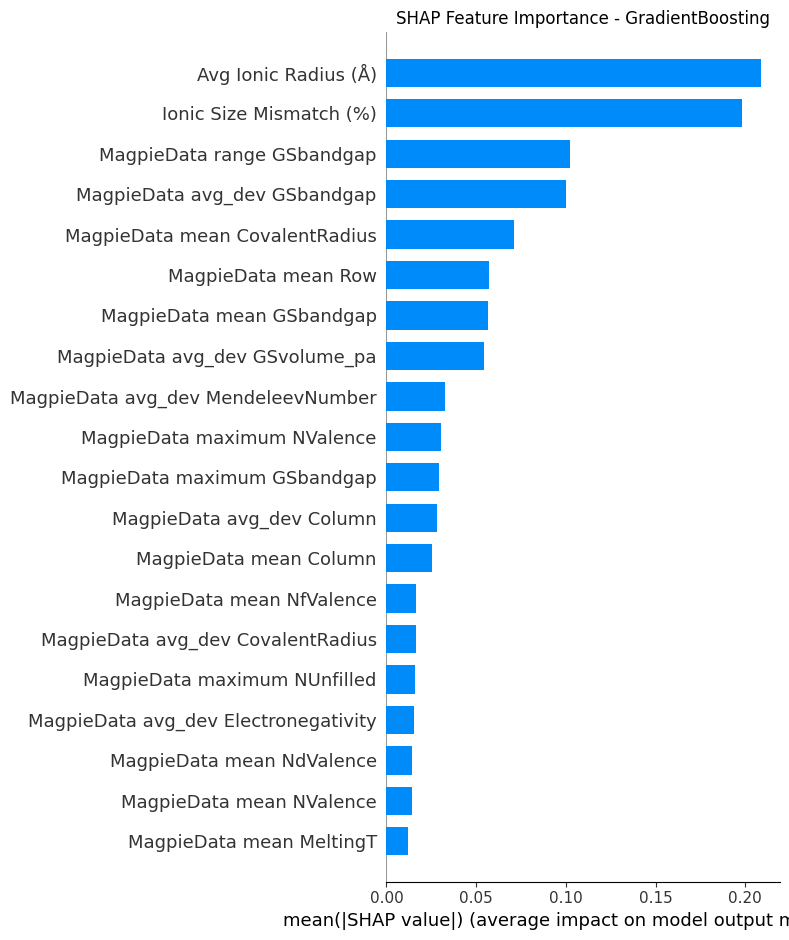

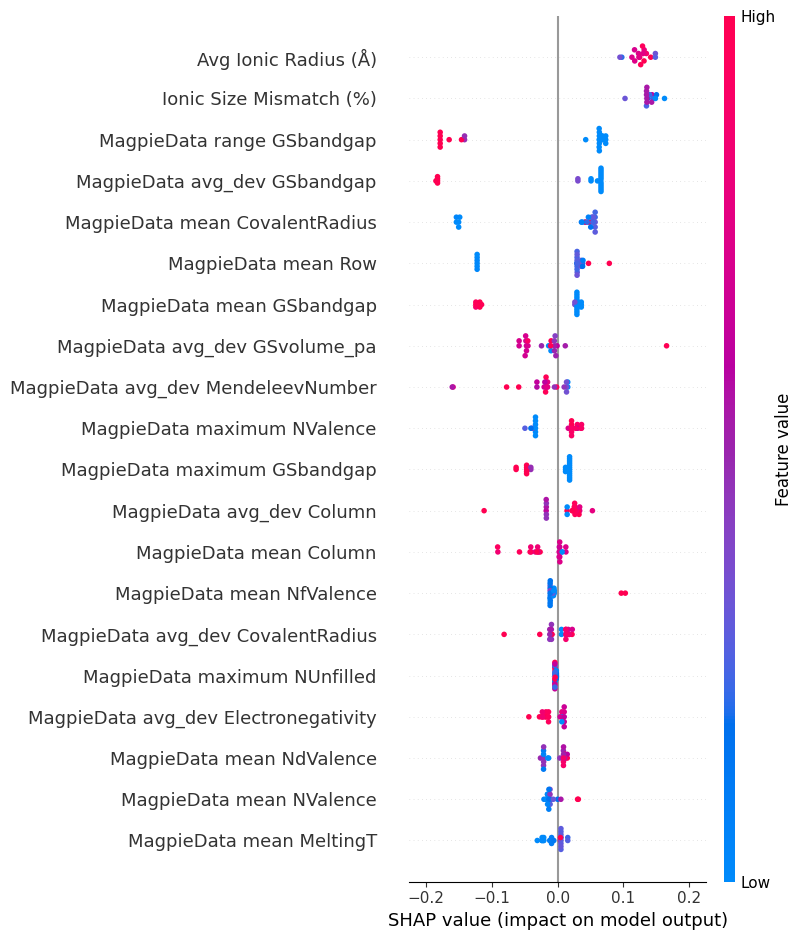


=== SHAP for RandomForest ===


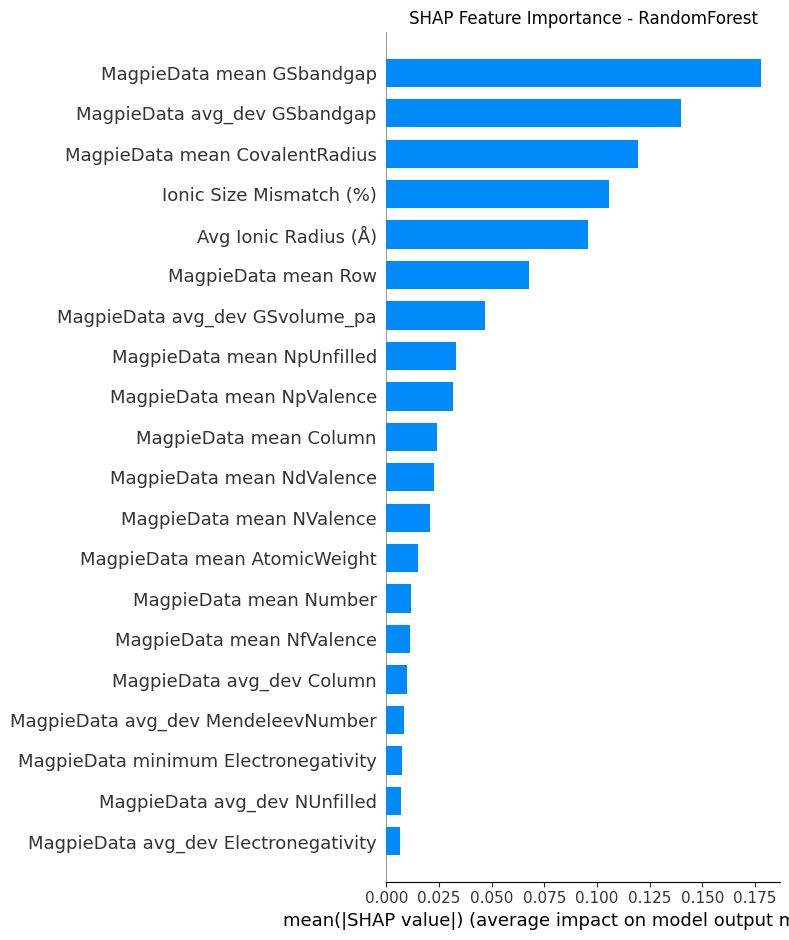

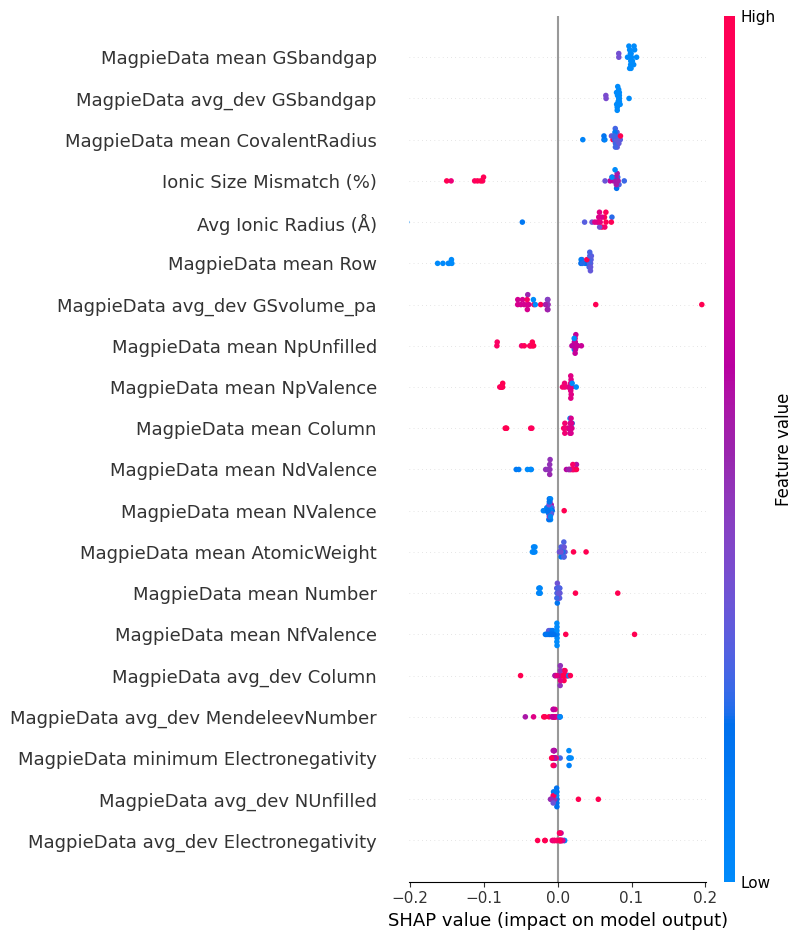


=== SHAP for Bagging_RF ===


  0%|          | 0/24 [00:00<?, ?it/s]

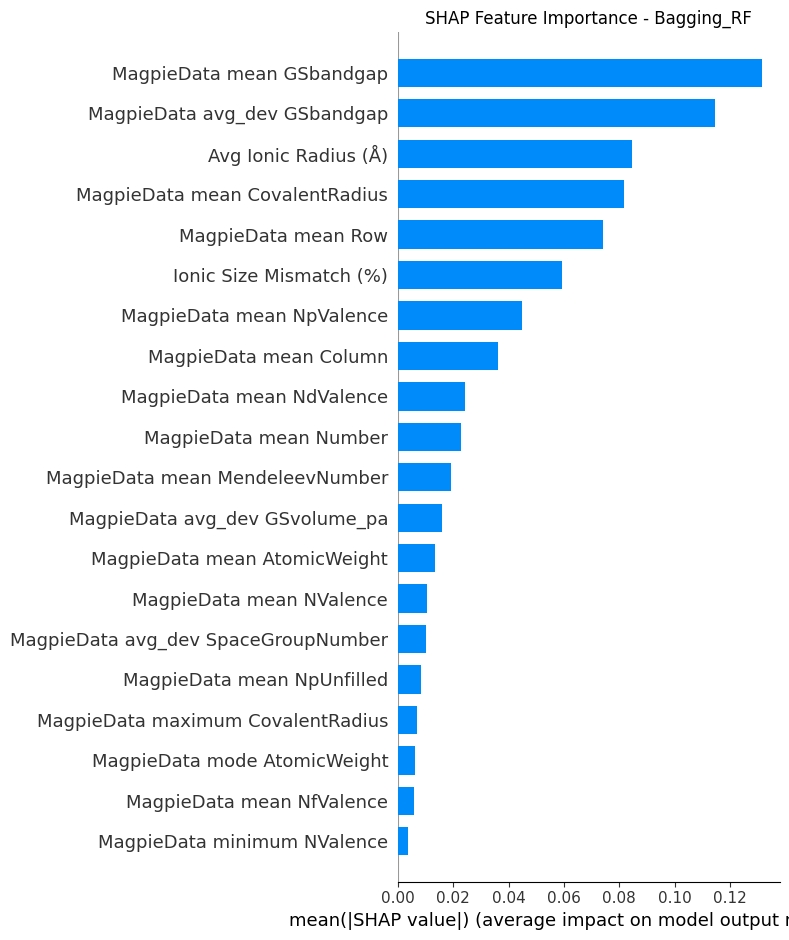

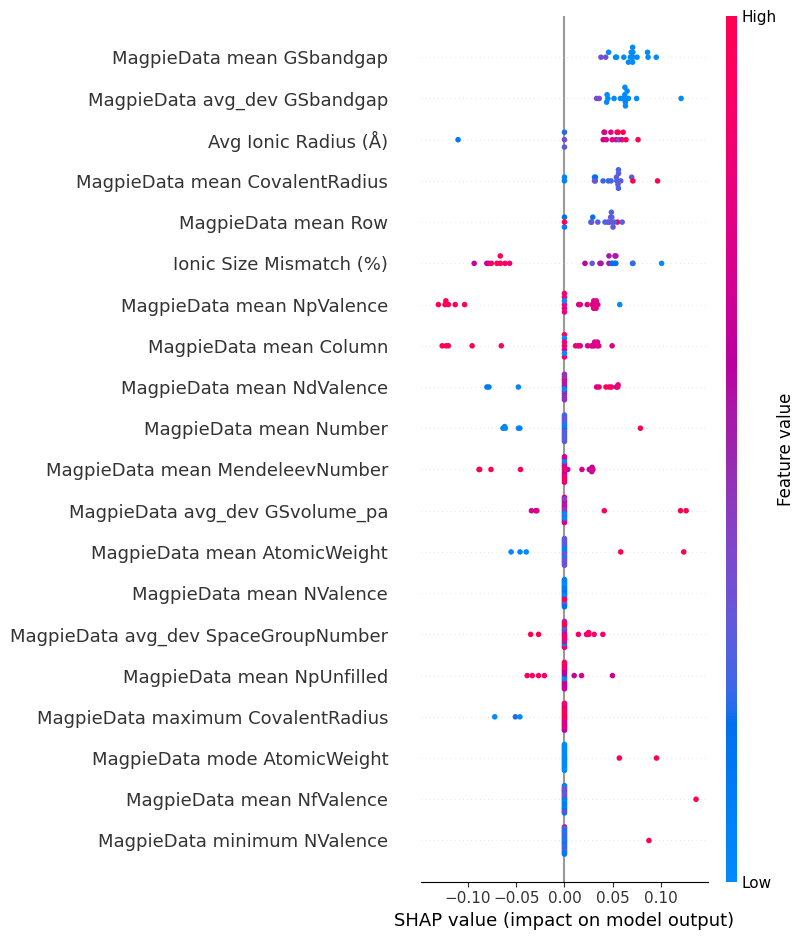


=== SHAP for AdaBoost ===


  0%|          | 0/24 [00:00<?, ?it/s]

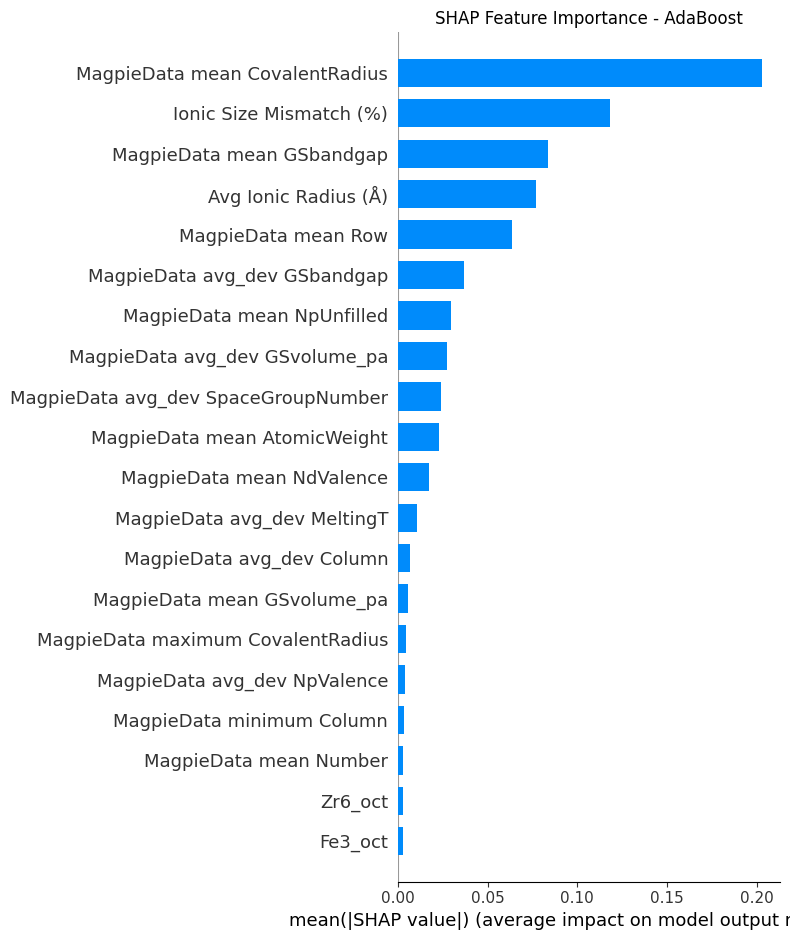

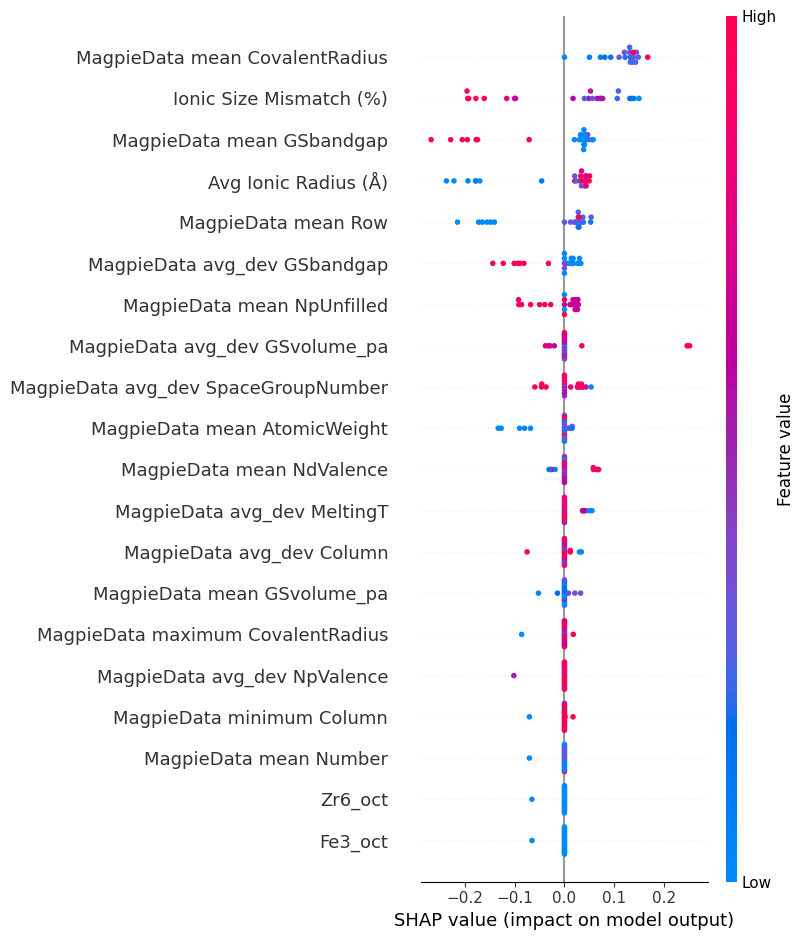


=== SHAP for Ridge ===


  0%|          | 0/24 [00:00<?, ?it/s]

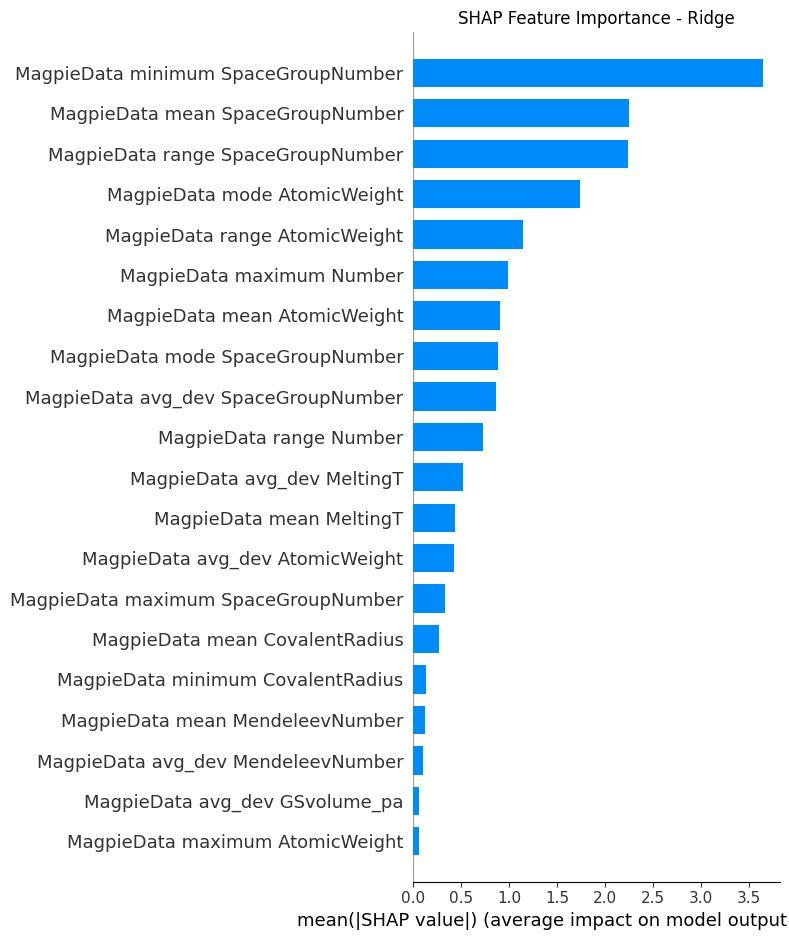

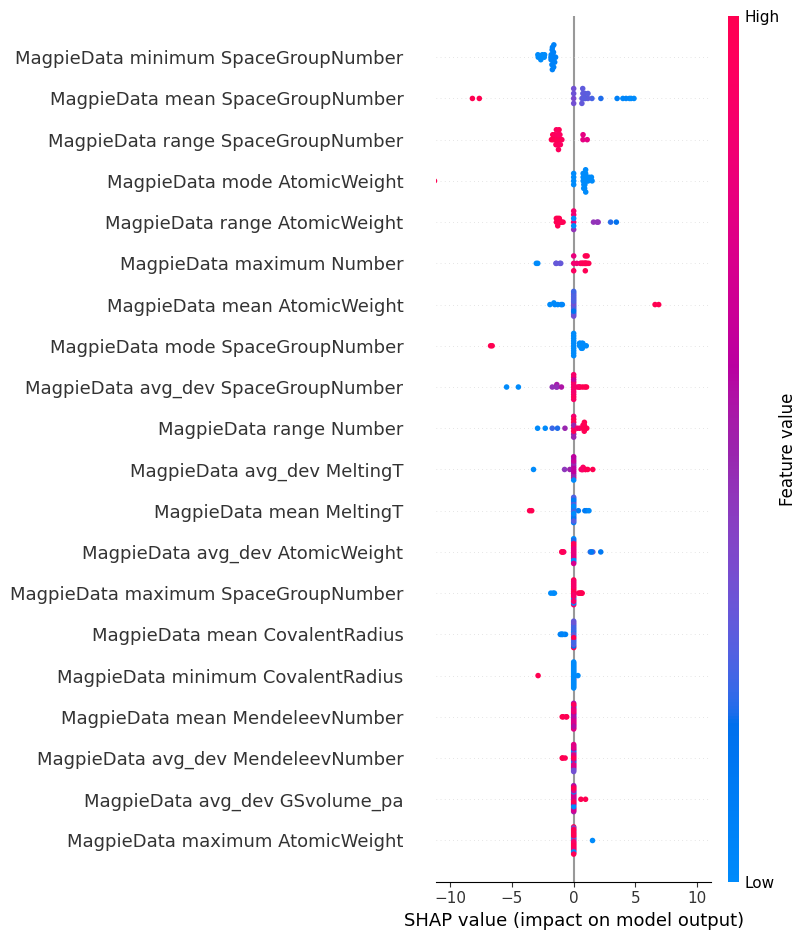


=== SHAP for KNN ===


  0%|          | 0/24 [00:00<?, ?it/s]

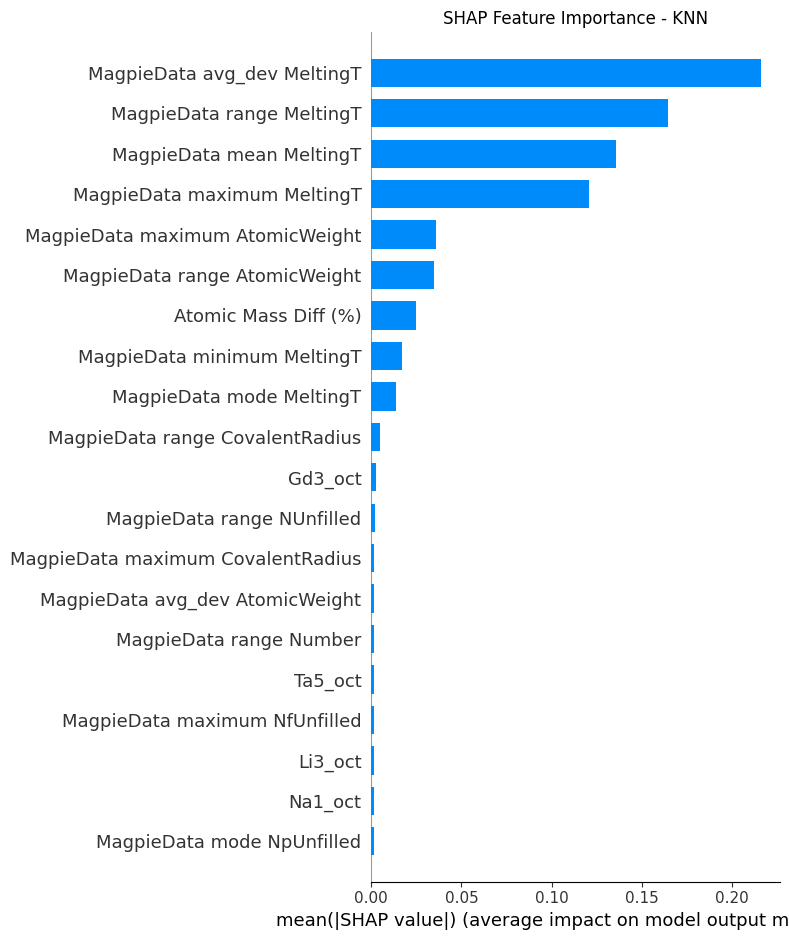

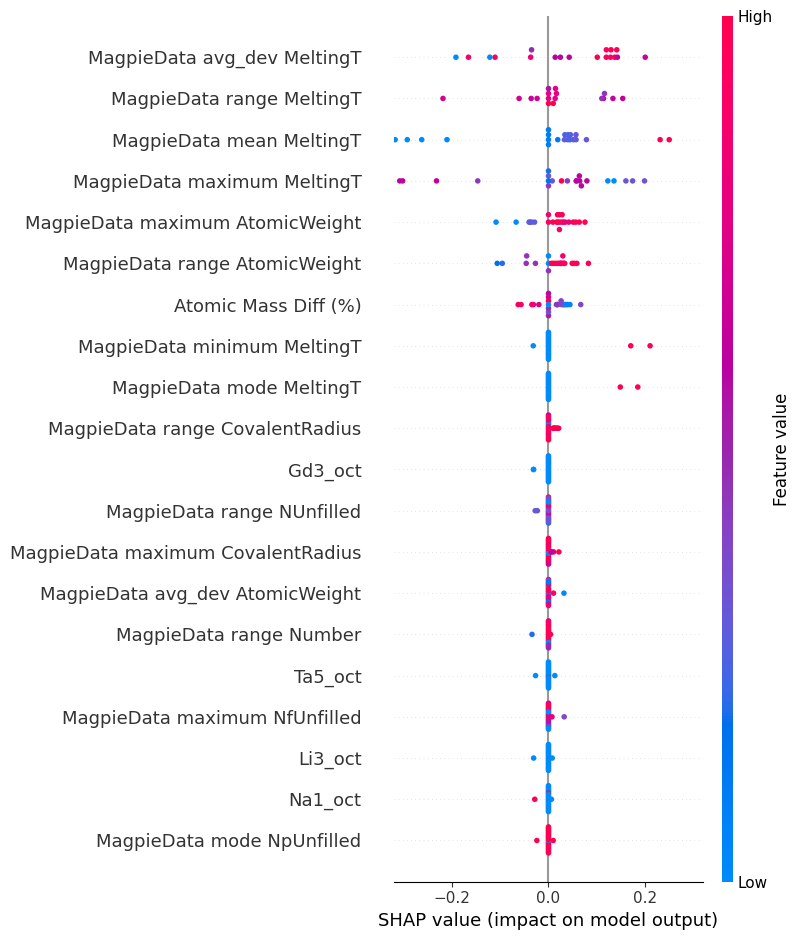

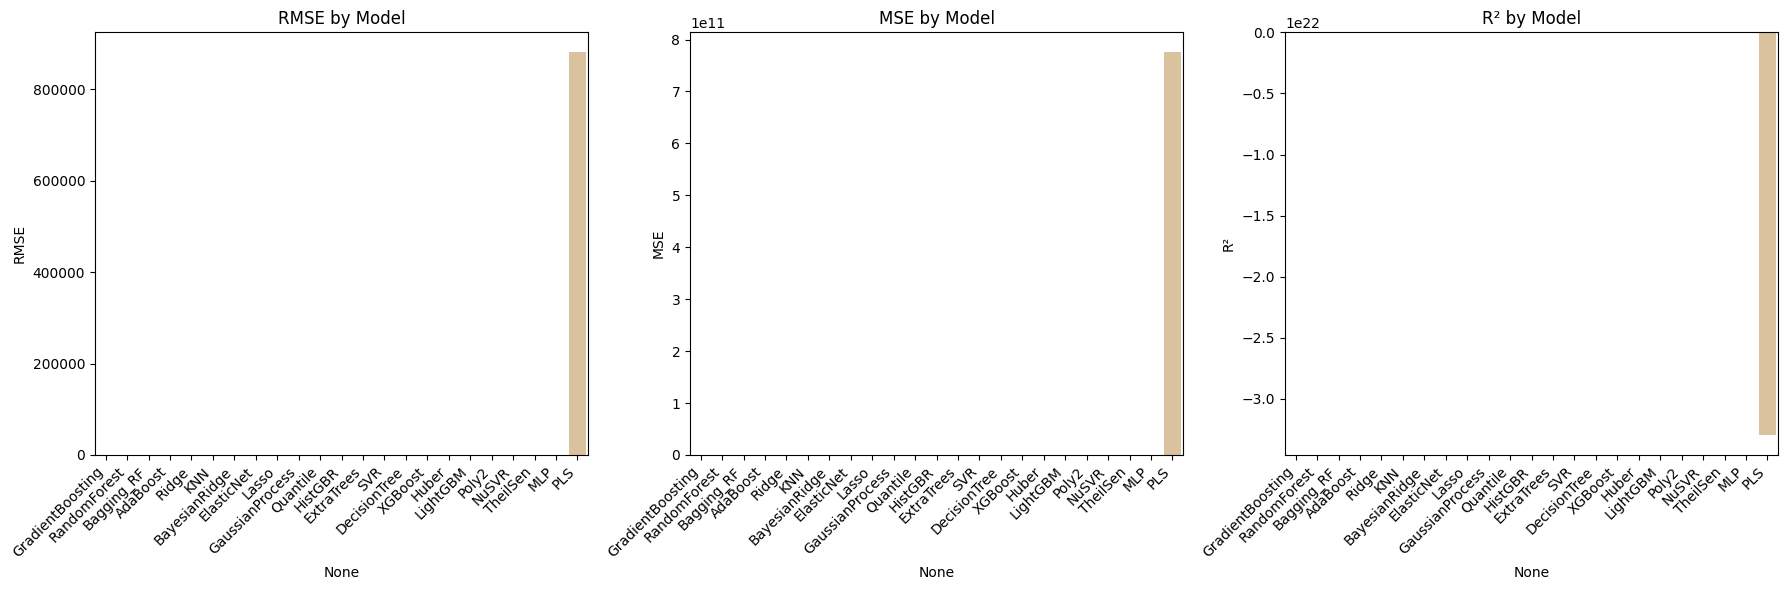

In [14]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    StackingRegressor,
    VotingRegressor,
    AdaBoostRegressor,
    BaggingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import (
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    HuberRegressor,
    TheilSenRegressor,
    TweedieRegressor,
    QuantileRegressor
)
from sklearn.svm import SVR, NuSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ---- Optional external libs ----
xgb_available = lgb_available = cat_available = False
try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    pass

try:
    from lightgbm import LGBMRegressor
    lgb_available = True
except Exception:
    pass

try:
    from catboost import CatBoostRegressor
    cat_available = True
except Exception:
    pass

warnings.filterwarnings("ignore")

# =========================
# Load and clean data
# =========================
df = pd.read_csv("composition_features_pymatgen.csv")
drop_cols = ["Composition", "Composition_clean", "input", "normalized", "pretty_formula", "Unnamed: 0"]
cols_to_drop = [c for c in drop_cols if c in df.columns]

target_column = "CTE Value"
if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' not found.")

y = df[target_column]
X = df.drop(columns=[target_column] + cols_to_drop, errors="ignore").select_dtypes(include=np.number)

print("Shape of X after dropping columns:", X.shape)

# Drop NaNs and align
X = X.dropna(axis=0)
y = y.loc[X.index]
print("Shape of X after dropping NaNs:", X.shape)

# Scale target (inverse later for metrics in original units)
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# =========================
# Train/test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

# =========================
# Model zoo (expanded)
# =========================
models = {
    # Tree models
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=0),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=500, random_state=0, n_jobs=-1),
    "DecisionTree": DecisionTreeRegressor(random_state=0),

    # Linear & regularized
    "Ridge": Ridge(alpha=1.0, random_state=0),
    "Lasso": Lasso(alpha=1e-3, random_state=0, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=1e-3, l1_ratio=0.5, random_state=0, max_iter=10000),
    "BayesianRidge": BayesianRidge(),
    "Huber": HuberRegressor(),
    "TheilSen": TheilSenRegressor(),
    "Tweedie": TweedieRegressor(power=1, alpha=0.5),
    "Quantile": QuantileRegressor(quantile=0.5, alpha=0.1, solver="highs"),

    # SVM/KNN
    "SVR": SVR(C=10.0, epsilon=0.01, kernel="rbf"),
    "NuSVR": NuSVR(kernel="rbf", C=1.0, nu=0.5),
    "KNN": KNeighborsRegressor(n_neighbors=7),

    # Neural net
    "MLP": MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000, random_state=0),

    # Histogram GB
    "HistGBR": HistGradientBoostingRegressor(random_state=0),

    # Gaussian Process
    "GaussianProcess": GaussianProcessRegressor(
        kernel=RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0),
        normalize_y=True, random_state=0
    ),

    # Partial Least Squares
    "PLS": PLSRegression(n_components=5),

    # Polynomial Regression
    "Poly2": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("lin", Ridge(alpha=1.0))
    ]),

    # Boosting/Bagging ensembles
    "AdaBoost": AdaBoostRegressor(n_estimators=300, random_state=0),
    "Bagging_RF": BaggingRegressor(
        estimator=RandomForestRegressor(n_estimators=50),
        n_estimators=20, random_state=0
    ),
}

if xgb_available:
    models["XGBoost"] = XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, tree_method="hist"
    )
if lgb_available:
    models["LightGBM"] = LGBMRegressor(
        n_estimators=800, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1
    )
if cat_available:
    models["CatBoost"] = CatBoostRegressor(
        iterations=1000, learning_rate=0.05, depth=6, random_seed=0, verbose=False
    )

# =========================
# Train & Evaluate
# =========================
results = {}
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = np.asarray(model.predict(X_test)).ravel()

        y_pred_orig = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
        y_test_orig = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

        mse = np.mean((y_test_orig - y_pred_orig) ** 2)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test_orig, y_pred_orig)

        results[name] = {"model": model, "MSE": mse, "RMSE": rmse, "R²": r2}
        print(f"\n{name}: R²={r2:.4f}, RMSE={rmse:.6e}, MSE={mse:.6e}")
    except Exception as e:
        print(f"{name} failed: {e}")

metrics_df = pd.DataFrame(results).T[["MSE", "RMSE", "R²"]].sort_values("R²", ascending=False)
print("\n=== Summary ===")
print(metrics_df)

# =========================
# SHAP on top-N models
# =========================
TOP_N_FOR_SHAP = 6
background_sample_size = 200
shap_sample_size = 400

tree_model_types = tuple([
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, DecisionTreeRegressor
] + ([XGBRegressor] if xgb_available else [])
  + ([LGBMRegressor] if lgb_available else [])
  + ([CatBoostRegressor] if cat_available else [])
)

top_models = metrics_df.head(TOP_N_FOR_SHAP).index.tolist()
print(f"\nRunning SHAP on top {len(top_models)} models by R²:", top_models)

rng = np.random.RandomState(42)
bg_idx = rng.choice(X_train.index, size=min(background_sample_size, len(X_train)), replace=False)
sample_idx = rng.choice(X_test.index, size=min(shap_sample_size, len(X_test)), replace=False)

X_bg = X.loc[bg_idx]
X_samp = X.loc[sample_idx]

for name in top_models:
    model = results[name]["model"]
    print(f"\n=== SHAP for {name} ===")
    try:
        if isinstance(model, tree_model_types):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_samp)
        else:
            explainer = shap.KernelExplainer(model.predict, shap.sample(X_bg, min(len(X_bg), 200), random_state=42))
            shap_values = explainer.shap_values(X_samp, nsamples="auto")

        shap.summary_plot(shap_values, X_samp, plot_type="bar", show=False)
        plt.title(f"SHAP Feature Importance - {name}")
        plt.tight_layout()
        plt.show()

        max_abs = np.max(np.abs(shap_values))
        plt.xlim(-0.5 * max_abs, 0.5 * max_abs)
        shap.summary_plot(shap_values, X_samp, plot_type="dot")
    except Exception as e:
        print(f"SHAP failed for {name}: {e}")

# =========================
# Metric plots
# =========================
palette = sns.color_palette("Set2", len(metrics_df))
color_dict = dict(zip(metrics_df.index, palette))

plt.figure(figsize=(18, 6))
for i, metric in enumerate(["RMSE", "MSE", "R²"]):
    plt.subplot(1, 3, i + 1)
    sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)
    plt.title(f"{metric} by Model")
    plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty

# --- [1] Your trained models ---
# Assumes `results` is a dict like: results[model_name] = {"model": model, "R²": ..., ...}
# And y_scaler is your StandardScaler for the target

# Use ALL models instead of only the top N
all_models = list(results.items())
print(f"Using all {len(all_models)} models: {[m[0] for m in all_models]}")

# --- [2] New compositions to predict ---
new_formulas = [
    "Y3Al5O12",
    "Y1.5Dy1.5Al5O12",
    "Y.9999Dy.9999Ho.9999Al5O12",
    "Y.75Dy.75Ho.75Er.75Al5O12",
    "Y.6La.6Dy.6Ho.6Er.6Al5O12",
    "Y.60Nd.60Dy.60Ho.60Er.6Al5O12",
    "(Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.1666)3Al5O12",
    "(Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285Ho0.14285Er0.14285)3Al5O12 ",
    "Y3Fe5O12",
    "Y3Fe2.50Al2.50O12",
    "Y3Fe2.475Al2.475Mn0.05O12",
    "Y3Fe2.475Al2.475Co0.05O12",
    "Y3Fe2.475Al2.475Ni0.05O12",
    "Y3Fe2.475Al2.475Cu0.05O12",
    "Y3Fe2.45Al2.45Mn0.025Co0.025Ni0.025Cu0.025O12",
    "Y.6Eu.6Dy.6Ho.6Er.6Al5O12",
    "La.666Gd.666Lu.666TiZrO7",
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7",
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7",
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7",
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7",
    "Eu.5Gd.5Ho.5Er.5Ti2O7",
    "GdHoTi2O7",
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7"
]

# --- [3] Featurize new compositions ---
comp_objs = []
for f in new_formulas:
    try:
        comp_objs.append(Composition(f))
    except Exception as e:
        print(f"Could not parse formula {f}: {e}")
        comp_objs.append(None)

valid_comp_objs = [c for c in comp_objs if c is not None]
valid_formulas = [f for f, c in zip(new_formulas, comp_objs) if c is not None]

feature_df = pd.DataFrame({"composition_obj": valid_comp_objs})
featurizer = ElementProperty.from_preset("magpie")
feature_df = featurizer.featurize_dataframe(feature_df, "composition_obj")

# --- [4] Align columns with training data ---
X_new = feature_df.reindex(columns=X.columns, fill_value=0.0)

# --- [5] Predict with each model in results ---
all_preds = {"Composition": valid_formulas}
for name, info in all_models:
    model = info["model"]
    y_pred_scaled = model.predict(X_new)
    y_pred_cte = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    all_preds[f"Predicted CTE ({name})"] = y_pred_cte

# --- [6] Output predictions ---
pred_df = pd.DataFrame(all_preds)
print(pred_df)

# --- [7] Save to CSV ---
pred_df.to_csv("cte_predictions_all_models.csv", index=False)


Using all 23 models: ['RandomForest', 'GradientBoosting', 'ExtraTrees', 'DecisionTree', 'Ridge', 'Lasso', 'ElasticNet', 'BayesianRidge', 'Huber', 'TheilSen', 'Quantile', 'SVR', 'NuSVR', 'KNN', 'MLP', 'HistGBR', 'GaussianProcess', 'PLS', 'Poly2', 'AdaBoost', 'Bagging_RF', 'XGBoost', 'LightGBM']


ElementProperty:   0%|          | 0/24 [00:00<?, ?it/s]

                                          Composition  \
0                                            Y3Al5O12   
1                                     Y1.5Dy1.5Al5O12   
2                          Y.9999Dy.9999Ho.9999Al5O12   
3                           Y.75Dy.75Ho.75Er.75Al5O12   
4                           Y.6La.6Dy.6Ho.6Er.6Al5O12   
5                       Y.60Nd.60Dy.60Ho.60Er.6Al5O12   
6   (Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.16...   
7   (Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285H...   
8                                            Y3Fe5O12   
9                                   Y3Fe2.50Al2.50O12   
10                          Y3Fe2.475Al2.475Mn0.05O12   
11                          Y3Fe2.475Al2.475Co0.05O12   
12                          Y3Fe2.475Al2.475Ni0.05O12   
13                          Y3Fe2.475Al2.475Cu0.05O12   
14      Y3Fe2.45Al2.45Mn0.025Co0.025Ni0.025Cu0.025O12   
15                          Y.6Eu.6Dy.6Ho.6Er.6Al5O12   
16                           La

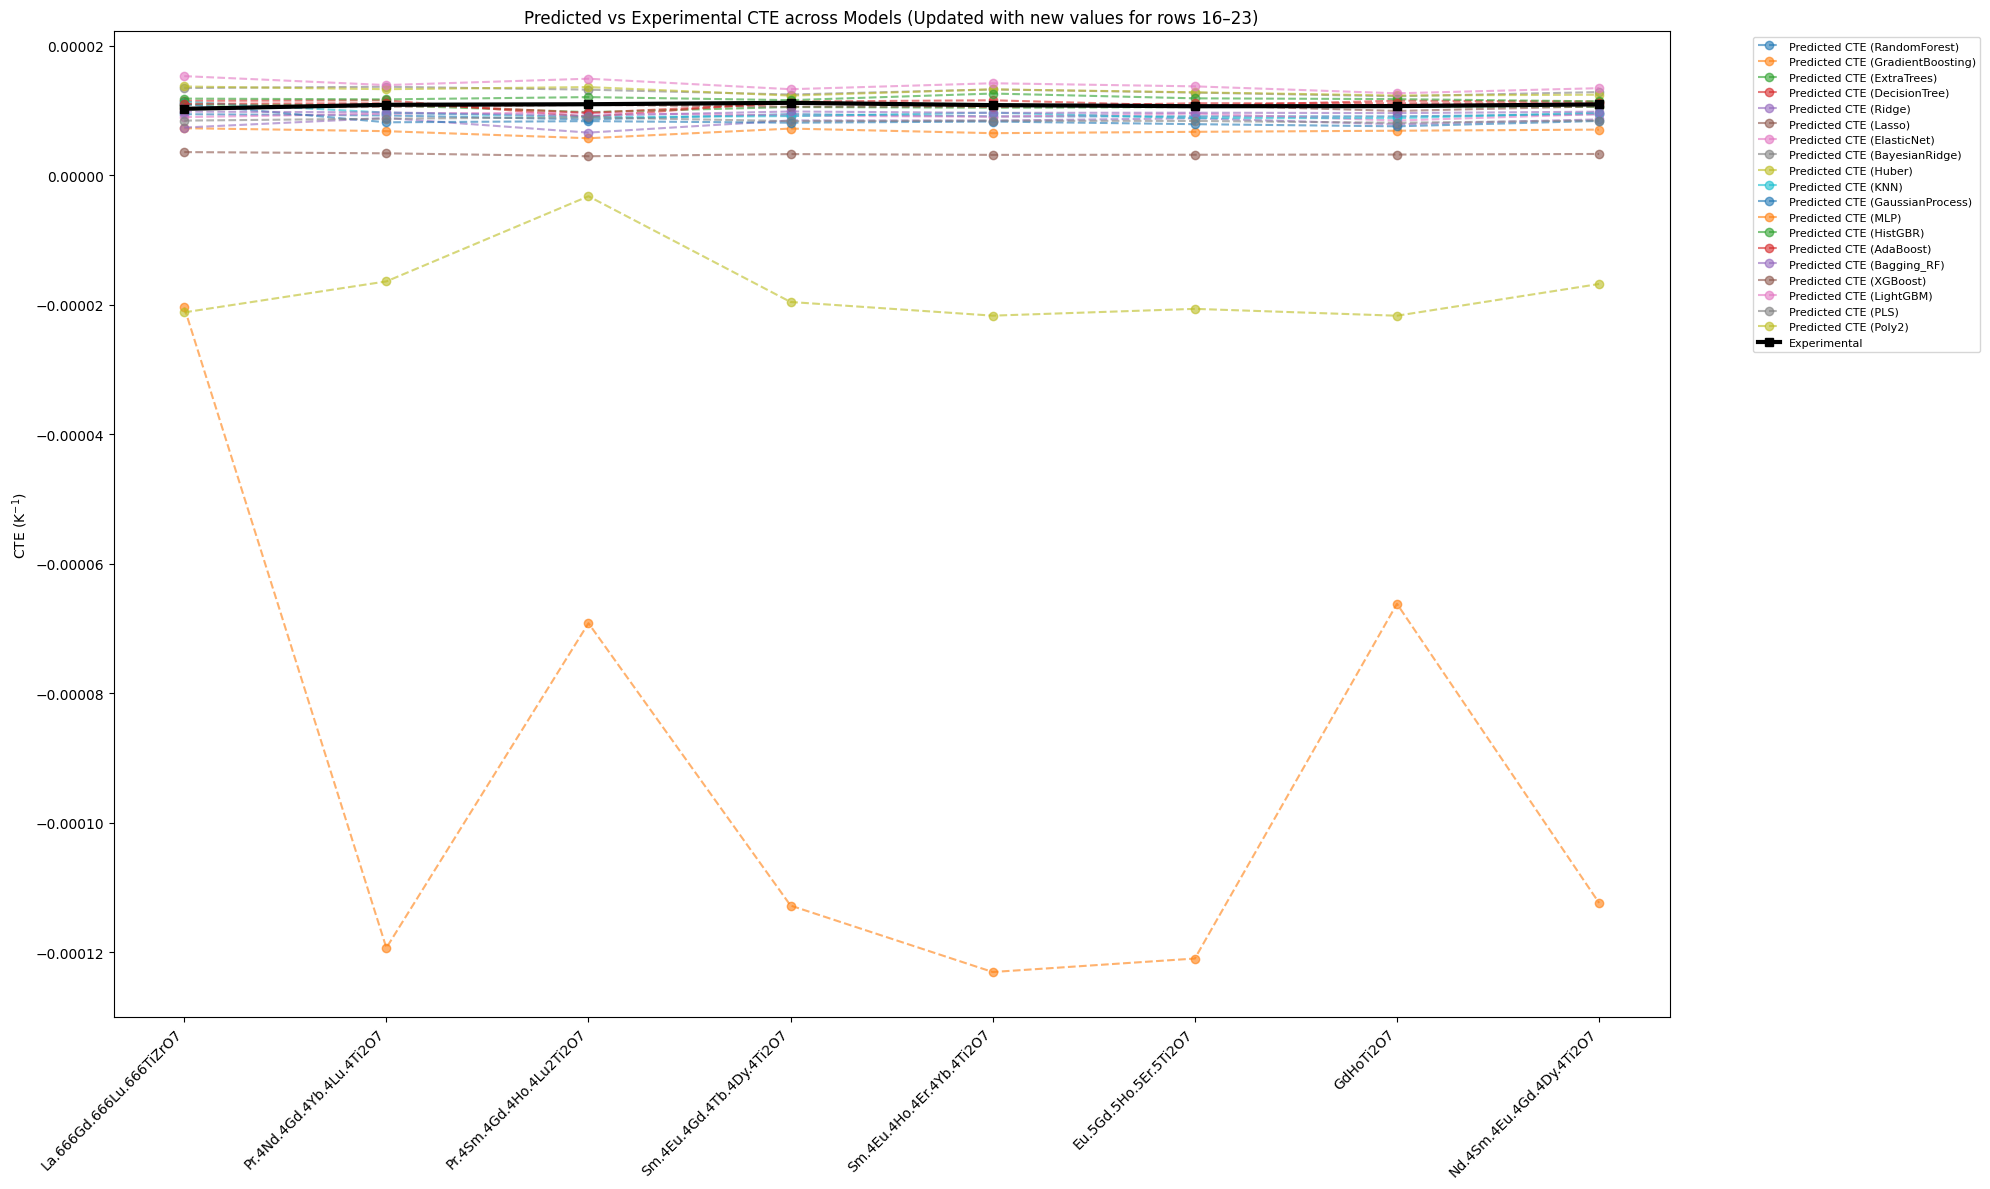

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------- Experimental Data ----------------
experimental_data = {
    "La.666Gd.666Lu.666TiZrO7": 10.26370957e-6,
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7": 10.8812864e-6,
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7": 10.97135822e-6,
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7": 11.18713217e-6,
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7": 10.83446e-6,
    "Eu.5Gd.5Ho.5Er.5Ti2O7": 10.66338e-6,
    "GdHoTi2O7": 10.68365e-6,
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7": 10.94286e-6,
}

# ---------------- Build DataFrame (rows 16–23 updated from your new table) ----------------
df = pd.DataFrame({
    "Formula": [
        "La.666Gd.666Lu.666TiZrO7",
        "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7",
        "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7",
        "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7",
        "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7",
        "Eu.5Gd.5Ho.5Er.5Ti2O7",
        "GdHoTi2O7",
        "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7"
    ],

    # Tree-based models (from indices 16–23)
    "Predicted CTE (RandomForest)":     [9.43e-6, 9.24e-6, 8.62e-6, 9.44e-6, 9.09e-6, 9.10e-6, 9.09e-6, 9.44e-6],
    "Predicted CTE (GradientBoosting)": [7.27e-6, 6.81e-6, 5.72e-6, 7.21e-6, 6.50e-6, 6.71e-6, 6.88e-6, 7.05e-6],
    "Predicted CTE (ExtraTrees)":       [10.92e-6, 10.81e-6, 9.75e-6, 10.54e-6, 10.43e-6, 10.53e-6, 10.59e-6, 10.56e-6],
    "Predicted CTE (DecisionTree)":     [11.50e-6, 11.58e-6, 9.04e-6, 11.38e-6, 11.58e-6, 10.72e-6, 11.52e-6, 11.38e-6],

    # Linear models
    "Predicted CTE (Ridge)":            [7.37e-6, 8.84e-6, 6.59e-6, 8.47e-6, 8.44e-6, 8.80e-6, 7.87e-6, 8.63e-6],
    "Predicted CTE (Lasso)":            [10.37e-6, 10.56e-6, 10.87e-6, 10.58e-6, 10.62e-6, 10.84e-6, 9.93e-6, 10.65e-6],
    "Predicted CTE (ElasticNet)":       [8.98e-6, 9.51e-6, 9.67e-6, 9.20e-6, 9.04e-6, 9.53e-6, 8.45e-6, 9.45e-6],
    "Predicted CTE (BayesianRidge)":    [13.47e-6, 13.67e-6, 13.22e-6, 12.47e-6, 13.25e-6, 12.77e-6, 12.20e-6, 12.85e-6],

    # Robust regressors
    "Predicted CTE (Huber)":            [13.71e-6, 13.29e-6, 13.62e-6, 12.30e-6, 13.27e-6, 12.81e-6, 12.32e-6, 12.44e-6],

    # Kernel & neighbors
    "Predicted CTE (KNN)":              [11.34e-6, 9.67e-6, 8.98e-6, 9.14e-6, 9.67e-6, 8.83e-6, 8.82e-6, 9.67e-6],
    "Predicted CTE (GaussianProcess)":  [10.98e-6, 8.18e-6, 8.36e-6, 8.12e-6, 8.30e-6, 7.89e-6, 7.56e-6, 8.39e-6],

    # Neural net / boosted variants
    "Predicted CTE (MLP)":              [-20.40e-6, -119.31e-6, -69.18e-6, -112.78e-6, -123.04e-6, -120.96e-6, -66.18e-6, -112.37e-6],
    "Predicted CTE (HistGBR)":          [11.84e-6, 11.72e-6, 12.07e-6, 11.60e-6, 12.62e-6, 11.88e-6, 11.76e-6, 11.41e-6],
    "Predicted CTE (AdaBoost)":         [11.04e-6, 11.12e-6, 9.64e-6, 11.12e-6, 10.59e-6, 11.12e-6, 11.12e-6, 11.12e-6],

    # Ensembles / GBDTs
    "Predicted CTE (Bagging_RF)":       [9.83e-6, 9.71e-6, 9.19e-6, 9.85e-6, 9.64e-6, 9.66e-6, 9.60e-6, 9.82e-6],
    "Predicted CTE (XGBoost)":          [3.58e-6, 3.39e-6, 2.94e-6, 3.27e-6, 3.15e-6, 3.17e-6, 3.20e-6, 3.29e-6],
    "Predicted CTE (LightGBM)":         [15.31e-6, 13.93e-6, 14.91e-6, 13.29e-6, 14.21e-6, 13.73e-6, 12.66e-6, 13.45e-6],

    # Other regressors
    "Predicted CTE (PLS)":              [8.44e-6, 8.74e-6, 8.95e-6, 8.35e-6, 8.43e-6, 8.39e-6, 8.11e-6, 8.45e-6],
    "Predicted CTE (Poly2)":            [-21.17e-6, -16.39e-6, -3.24e-6, -19.57e-6, -21.68e-6, -20.63e-6, -21.69e-6, -16.79e-6],
})

# Add experimental values
df["Experimental"] = df["Formula"].map(experimental_data)

# ---------------- Collect model columns ----------------
model_cols = [c for c in df.columns if c.startswith("Predicted CTE")]

# ---------------- Plotting ----------------
plt.figure(figsize=(20, 12))
for model in model_cols:
    plt.plot(df["Formula"], df[model], marker="o", linestyle="--", alpha=0.6, label=model)

# Plot experimental
plt.plot(df["Formula"], df["Experimental"], marker="s", color="black", linewidth=3, label="Experimental")

plt.xticks(rotation=45, ha="right")
plt.ylabel("CTE (K$^{-1}$)")
plt.title("Predicted vs Experimental CTE across Models (Updated with new values for rows 16–23)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


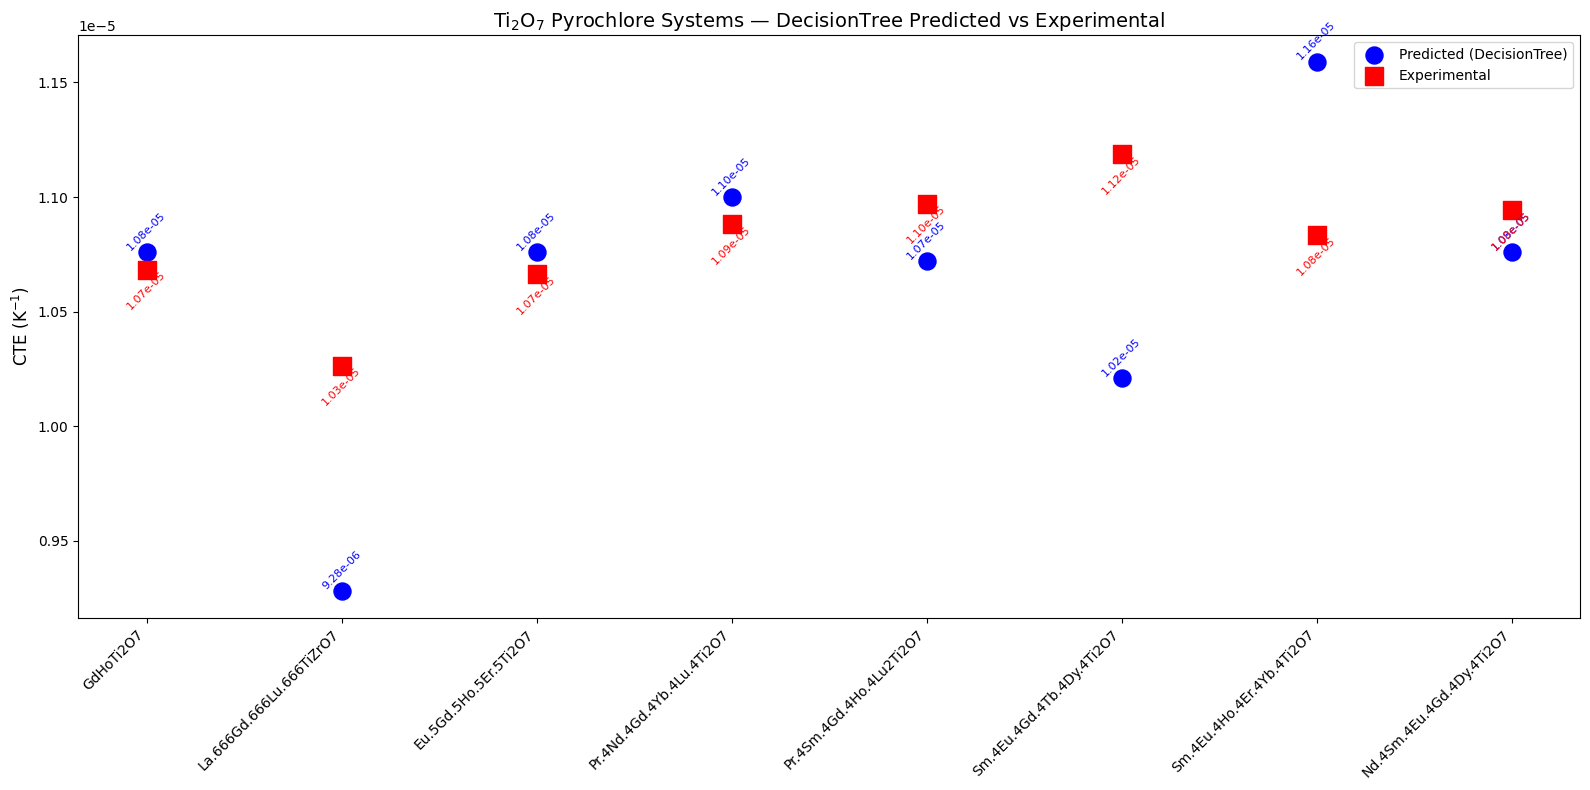

In [17]:
import matplotlib.pyplot as plt
import re

# ---------------- Predicted Data (DecisionTree only; rows 15–22) ----------------
predicted_data = {
    "La.666Gd.666Lu.666TiZrO7": 9.28e-6,
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7": 11.00e-6,
    "Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7": 10.72e-6,
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7": 10.21e-6,
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7": 11.59e-6,
    "Eu.5Gd.5Ho.5Er.5Ti2O7": 10.76e-6,
    "GdHoTi2O7": 10.76e-6,
    "Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7": 10.76e-6,
}

# ---------------- Experimental Data ----------------
experimental_data = {
    "[La/Gd/Lu]2[Ti/Zr]2O7": 10.26370957e-6,
    "[Pr/Nd/Gd/Yb/Lu]2Ti2O7": 10.8812864e-6,
    "[Pr/Sm/Gd/Ho/Lu]2Ti2O7": 10.97135822e-6,
    "[Sm/Eu/Gd/Tb/Dy]2Ti2O7": 11.18713217e-6,
    "[Sm/Eu/Ho/Er/Yb]2Ti2O7": 10.83446e-6,
    "[Eu/Gd/Ho/Er]2Ti2O7": 10.66338e-6,
    "[Gd/Ho]2Ti2O7": 10.68365e-6,
    "[Nd/Sm/Eu/Gd/Dy]2Ti2O7": 10.94286e-6,
}

# ---------------- Helpers ----------------
def count_unique_elements(formula: str) -> int:
    elements = re.findall(r'[A-Z][a-z]?', formula)
    return len(set(elements))

def map_key(key: str) -> str:
    return "".join(re.findall(r'[A-Z][a-z]?', key))

# Create unified dataset (map predicted + experimental)
combined = []
for pkey, pval in predicted_data.items():
    short = map_key(pkey)
    match = None
    for ekey, eval_ in experimental_data.items():
        if map_key(ekey) == short:
            match = eval_
            break
    combined.append((pkey, pval, match))

# Sort by compositional complexity
combined_sorted = sorted(combined, key=lambda x: count_unique_elements(x[0]))

# ---------------- Plotting ----------------
plt.figure(figsize=(16, 8))

labels = [c[0] for c in combined_sorted]
pred_vals = [c[1] for c in combined_sorted]
exp_vals = [c[2] for c in combined_sorted]

# Plot predicted (DecisionTree)
plt.scatter(range(len(pred_vals)), pred_vals, s=150, color="blue",
            label="Predicted (DecisionTree)", marker="o")
# Plot experimental
plt.scatter(range(len(exp_vals)), exp_vals, s=150, color="red",
            label="Experimental", marker="s")

# Annotate with values
for i, (p, e) in enumerate(zip(pred_vals, exp_vals)):
    plt.text(i, p, f"{p:.2e}", ha="center", va="bottom",
             fontsize=8, color="blue", rotation=45)
    if e is not None:
        plt.text(i, e, f"{e:.2e}", ha="center", va="top",
                 fontsize=8, color="red", rotation=45)

plt.xticks(range(len(labels)), labels, rotation=45, ha="right", fontsize=10)
plt.ylabel("CTE (K$^{-1}$)", fontsize=12)
plt.title("Ti$_2$O$_7$ Pyrochlore Systems — DecisionTree Predicted vs Experimental", fontsize=14)
plt.legend()
plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()


# Your Turn

You're final dataset for model training will be the file "composition_features_pymatgen.csv"

In [18]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("composition_features_pymatgen.csv")

# Display the first 5 rows
display(df.head())

,Composition,CTE Value,Al3_oct,Al3_tet,Ba2_oct,Be3_oct,Ca2_multi,Ca2_oct,Ce-22_oct,Ce3_multi,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,Y0.5Yb0.5Ta0.5Nb0.5ZrO7,0.00001075,0.00000000,0,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,229.00000000,217.00000000,71.65000000,83.51000000,12.00000000
1,Y0.4175Yb0.4175Ta0.4175Nb0.4175ZrO6.67,0.00001075,0.00000000,0,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,229.00000000,217.00000000,68.54850000,80.76256770,12.00000000
2,Al2O3Y0.6Er0.6Yb0.6Ho0.6Lu0.6Al5O12,0.00000810,7.00000000,0,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00224710,0.00005393,0.00010527,0.00000000,12.00000000,225.00000000,213.00000000,94.22400000,98.66880000,12.00000000
3,Al2O3Y3Al5O12,0.00000800,7.00000000,0,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,93.48000000,97.77600000,12.00000000
4,La0.4Nd0.4Sm0.4Eu0.4Gd0.4Zr2O7,0.00001304,0.00000000,0,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,229.00000000,217.00000000,78.45310938,84.56460470,12.00000000


In [19]:
# Get the list of column names
column_names = df.columns.tolist()

# Print the column names
print(column_names)

['Composition', 'CTE Value', 'Al3_oct', 'Al3_tet', 'Ba2_oct', 'Be3_oct', 'Ca2_multi', 'Ca2_oct', 'Ce-22_oct', 'Ce3_multi', 'Ce3_oct', 'Ce4_multi', 'Ce4_oct', 'Co2_oct', 'Cr3_oct', 'Dy3_multi', 'Dy3_oct', 'Er3_multi', 'Er3_oct', 'Eu3_multi', 'Eu3_oct', 'Fe2_oct', 'Fe3_oct', 'Fe3_tet', 'Ga3_oct', 'Gd3_multi', 'Gd3_oct', 'Gd3_tet', 'Hf2_oct', 'Hf4_oct', 'Ho3_multi', 'Ho3_oct', 'La1_oct', 'La3_multi', 'La3_oct', 'La3_tet', 'Li3_oct', 'Li3_tet', 'Lu3_multi', 'Lu3_oct', 'Mg2_oct', 'Mn2_oct', 'Mn4_oct', 'Na1_multi', 'Na1_oct', 'Nb5_oct', 'Nd3_multi', 'Nd3_oct', 'Nd3_tet', 'Ni3_oct', 'P5_oct', 'P5_tet', 'Pr3_multi', 'Pr3_oct', 'Pr3_tet', 'Sc3_oct', 'Si2_oct', 'Si3_oct', 'Si4_oct', 'Sm3_multi', 'Sm3_oct', 'Sm3_tet', 'Sr2_oct', 'Ta5_oct', 'Ti4_oct', 'Tm3_oct', 'U6_oct', 'Y3_multi', 'Y3_oct', 'Yb2_oct', 'Yb3_multi', 'Yb3_oct', 'Zr4_multi', 'Zr4_oct', 'Zr6_oct', 'Zr7_oct', 'Avg Ionic Radius (Å)', 'Ionic Size Mismatch (%)', 'Atomic Mass Diff (%)', 'Composition_clean', 'normalized', 'pretty_formula'

## Find 10 important features

First, I will build a simple regressor and do SHAP analysis in order to find top ten features by importance

Test MSE: 0.000000

Top-10 features by mean |SHAP| on the test set:
 1. MagpieData mean GSbandgap: 0.000000
 2. MagpieData mean Row: 0.000000
 3. MagpieData avg_dev GSbandgap: 0.000000
 4. Avg Ionic Radius (Å): 0.000000
 5. MagpieData mean Number: 0.000000
 6. MagpieData mean AtomicWeight: 0.000000
 7. Ionic Size Mismatch (%): 0.000000
 8. MagpieData maximum GSbandgap: 0.000000
 9. MagpieData maximum AtomicWeight: 0.000000
10. MagpieData mean CovalentRadius: 0.000000


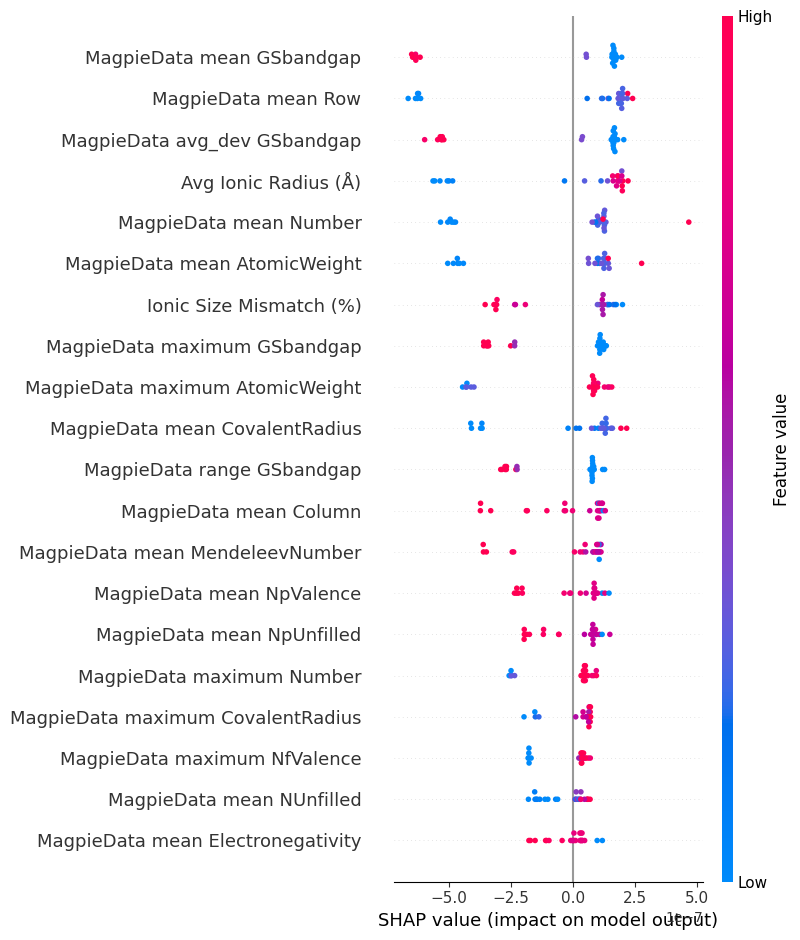

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import shap

# ---------- 1) Prepare data ----------
# Assumes you already have a DataFrame `df` with columns: "composition", "CTE", and many feature columns.
target_col = "CTE Value"
drop_cols = ["composition", target_col]

# Use all columns except composition and target as features; keep only numeric columns.
X = df.drop(columns=drop_cols, errors="ignore")
X = X.select_dtypes(include=[np.number]).copy()
y = df[target_col].astype(float).copy()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------- 2) Model pipeline & training ----------
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=500,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

pipe.fit(X_train, y_train)

# ---------- 3) Evaluation (MSE) ----------
y_pred = pipe.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.6f}")

# ---------- 4) SHAP analysis (top-10 features) ----------
# SHAP with tree-based models is fast/accurate using TreeExplainer.
rf_model = pipe.named_steps["rf"]
imputer = pipe.named_steps["imputer"]

# Impute X_test the same way the pipeline does (so SHAP sees actual model inputs)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

explainer = shap.TreeExplainer(rf_model)

# Handle both new/old SHAP APIs
try:
    # Newer API (returns shap.Explanation)
    shap_expl = explainer(X_test_imp)
    shap_vals = np.abs(shap_expl.values).mean(axis=0)
except Exception:
    # Older API
    shap_vals = np.abs(explainer.shap_values(X_test_imp)).mean(axis=0)

importance = pd.Series(shap_vals, index=X.columns).sort_values(ascending=False)
top10 = importance.head(10)

print("\nTop-10 features by mean |SHAP| on the test set:")
for i, (feat, val) in enumerate(top10.items(), start=1):
    print(f"{i:>2}. {feat}: {val:.6f}")

# (Optional) quick SHAP plots (comment in if you want visuals)
shap.summary_plot(shap_expl.values if 'shap_expl' in locals() else explainer.shap_values(X_test_imp),
                   X_test_imp, show=False)
#shap.plots.bar(shap_expl, show=False)  # for newer SHAP


In [21]:
# --- 1) Top-10 feature importance as a DataFrame ---
top10_importance_df = (
    top10.rename("mean_abs_shap")
         .reset_index()
         .rename(columns={"index": "feature"})
)
print(top10_importance_df.head(10))

# --- 2) Original df with only the top-10 features (+ composition, CTE if present) ---
top10_features = top10.index.tolist()
cols_keep = [c for c in ["composition", "CTE"] if c in df.columns] + top10_features
df_top10_features = df[cols_keep].copy()
print(df_top10_features.shape, "rows x cols")

# (Optional) If you want the IMPUTED values version used by the model:
# (requires `imputer` and `X` from your pipeline code above)
# X_imp = pd.DataFrame(imputer.transform(X), columns=X.columns, index=X.index)
# X_top10_imp = X_imp[top10_features].copy()

# (Optional) Save to CSV
# top10_importance_df.to_csv("top10_feature_importance.csv", index=False)
# df_top10_features.to_csv("df_top10_features.csv", index=False)


                           feature  mean_abs_shap
0        MagpieData mean GSbandgap     0.00000029
1              MagpieData mean Row     0.00000029
2     MagpieData avg_dev GSbandgap     0.00000027
3             Avg Ionic Radius (Å)     0.00000025
4           MagpieData mean Number     0.00000022
5     MagpieData mean AtomicWeight     0.00000021
6          Ionic Size Mismatch (%)     0.00000019
7     MagpieData maximum GSbandgap     0.00000019
8  MagpieData maximum AtomicWeight     0.00000018
9   MagpieData mean CovalentRadius     0.00000017
(118, 10) rows x cols


In [22]:
df

,Composition,CTE Value,Al3_oct,Al3_tet,Ba2_oct,Be3_oct,Ca2_multi,Ca2_oct,Ce-22_oct,Ce3_multi,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,Y0.5Yb0.5Ta0.5Nb0.5ZrO7,0.00001075,0.00000000,0,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,229.00000000,217.00000000,71.65000000,83.51000000,12.00000000
1,Y0.4175Yb0.4175Ta0.4175Nb0.4175ZrO6.67,0.00001075,0.00000000,0,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,229.00000000,217.00000000,68.54850000,80.76256770,12.00000000
2,Al2O3Y0.6Er0.6Yb0.6Ho0.6Lu0.6Al5O12,0.00000810,7.00000000,0,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00224710,0.00005393,0.00010527,0.00000000,12.00000000,225.00000000,213.00000000,94.22400000,98.66880000,12.00000000
3,Al2O3Y3Al5O12,0.00000800,7.00000000,0,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,93.48000000,97.77600000,12.00000000
4,La0.4Nd0.4Sm0.4Eu0.4Gd0.4Zr2O7,0.00001304,0.00000000,0,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,229.00000000,217.00000000,78.45310938,84.56460470,12.00000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,Y0.6Dy0.6Ho0.6Er0.6Yb0.6Al5O12,0.00000928,2.00000000,3,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,93.48000000,97.77600000,12.00000000
114,Yb3Al5O12,0.00000783,2.00000000,3,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,12.00000000,225.00000000,213.00000000,97.20000000,102.24000000,12.00000000
115,Y0.6Yb0.6Lu0.6Eu0.6Er0.6Al5O12,0.00000854,2.00000000,3,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00224710,0.00006741,0.00013078,0.00000000,12.00000000,229.00000000,217.00000000,94.53000000,99.03600000,12.00000000
116,Ho0.5Lu0.5Yb0.5Eu0.5SiO5,0.00000495,0.00000000,0,0,0,0.00000000,0.00000000,0,0.00000000,...,0.00224710,0.00014044,0.00026333,0.00000000,12.00000000,229.00000000,217.00000000,88.50000000,95.62500000,12.00000000


In [23]:
# Create a list of columns to keep: the target column and the top 10 features
columns_to_keep = ["CTE Value"] + top10_features

# Create the new DataFrame by selecting these columns from the original DataFrame
df_important = df[columns_to_keep].copy()

# Display the head of the new DataFrame to verify
display(df_important.head())

,CTE Value,MagpieData mean GSbandgap,MagpieData mean Row,MagpieData avg_dev GSbandgap,Avg Ionic Radius (Å),MagpieData mean Number,MagpieData mean AtomicWeight,Ionic Size Mismatch (%),MagpieData maximum GSbandgap,MagpieData maximum AtomicWeight,MagpieData mean CovalentRadius
0,0.00001075,0.00000000,3.00000000,0.00000000,1.14840000,20.75000000,47.11268550,15.62000000,0.00000000,180.94788000,99.25000000
1,0.00001075,0.00000000,2.94710000,0.00000000,1.15320000,19.96490000,45.14615266,15.35000000,0.00000000,180.94788000,97.65480000
2,0.00000810,0.00000000,2.73600000,0.00000000,1.06790000,16.00000000,35.61325409,23.99000000,0.00000000,174.96680000,96.16000000
3,0.00000800,0.00000000,2.64000000,0.00000000,1.06980000,13.12000000,27.82317281,23.91000000,0.00000000,88.90585000,96.28000000
4,0.00001304,0.00000000,3.27314537,0.00000000,1.16830000,23.49690062,53.79084470,13.24000000,0.00000000,157.25000000,110.19536093


## Run causal analysis with gCastle

In [24]:
!pip install gcastle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.4/214.4 kB 5.3 MB/s eta 0:00:00


Variables (11): ['CTE Value', 'MagpieData mean GSbandgap', 'MagpieData mean Row', 'MagpieData avg_dev GSbandgap', 'Avg Ionic Radius (Å)', 'MagpieData mean Number', 'MagpieData mean AtomicWeight', 'Ionic Size Mismatch (%)', 'MagpieData maximum GSbandgap', 'MagpieData maximum AtomicWeight', 'MagpieData mean CovalentRadius']
Matrix shape: (118, 11)
PC done
NoTEARS done
GOLEM done
PC adjacency (0/1):


,CTE Value,MagpieData mean GSbandgap,MagpieData mean Row,MagpieData avg_dev GSbandgap,Avg Ionic Radius (Å),MagpieData mean Number,MagpieData mean AtomicWeight,Ionic Size Mismatch (%),MagpieData maximum GSbandgap,MagpieData maximum AtomicWeight,MagpieData mean CovalentRadius
CTE Value,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,1.00000000,0.00000000
MagpieData mean GSbandgap,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000
MagpieData mean Row,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,1.00000000,0.00000000,0.00000000,0.00000000,1.00000000
MagpieData avg_dev GSbandgap,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000
Avg Ionic Radius (Å),0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,1.00000000,0.00000000
MagpieData mean Number,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,1.00000000
MagpieData mean AtomicWeight,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000
Ionic Size Mismatch (%),0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
MagpieData maximum GSbandgap,0.00000000,1.00000000,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
MagpieData maximum AtomicWeight,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000


NOTEARS adjacency (weights):


,CTE Value,MagpieData mean GSbandgap,MagpieData mean Row,MagpieData avg_dev GSbandgap,Avg Ionic Radius (Å),MagpieData mean Number,MagpieData mean AtomicWeight,Ionic Size Mismatch (%),MagpieData maximum GSbandgap,MagpieData maximum AtomicWeight,MagpieData mean CovalentRadius
CTE Value,0,1,0,0,0,0,0,0,0,0,0
MagpieData mean GSbandgap,0,0,0,1,0,0,0,0,0,1,0
MagpieData mean Row,0,0,0,0,0,1,0,0,0,0,1
MagpieData avg_dev GSbandgap,0,0,0,0,0,0,0,0,1,0,0
Avg Ionic Radius (Å),0,0,0,0,0,0,0,1,0,0,0
MagpieData mean Number,0,0,0,0,0,0,1,0,0,0,0
MagpieData mean AtomicWeight,1,0,0,0,0,0,0,0,0,0,0
Ionic Size Mismatch (%),0,0,1,0,0,0,0,0,0,0,0
MagpieData maximum GSbandgap,0,0,0,0,1,0,0,0,0,0,0
MagpieData maximum AtomicWeight,0,0,0,0,0,0,0,0,0,0,0


GOLEM adjacency (weights):


,CTE Value,MagpieData mean GSbandgap,MagpieData mean Row,MagpieData avg_dev GSbandgap,Avg Ionic Radius (Å),MagpieData mean Number,MagpieData mean AtomicWeight,Ionic Size Mismatch (%),MagpieData maximum GSbandgap,MagpieData maximum AtomicWeight,MagpieData mean CovalentRadius
CTE Value,0,0,0,0,0,0,0,0,0,0,0
MagpieData mean GSbandgap,1,0,0,0,0,0,0,0,0,1,0
MagpieData mean Row,0,0,0,0,1,1,0,0,1,0,1
MagpieData avg_dev GSbandgap,0,1,0,0,0,0,0,0,0,1,0
Avg Ionic Radius (Å),0,0,0,0,0,0,0,0,1,1,0
MagpieData mean Number,0,0,0,0,1,0,0,0,1,1,0
MagpieData mean AtomicWeight,0,0,1,0,1,1,0,0,0,0,1
Ionic Size Mismatch (%),0,0,0,0,1,0,1,0,1,1,0
MagpieData maximum GSbandgap,0,0,0,1,0,0,0,0,0,1,0
MagpieData maximum AtomicWeight,0,0,0,0,0,0,0,0,0,0,0


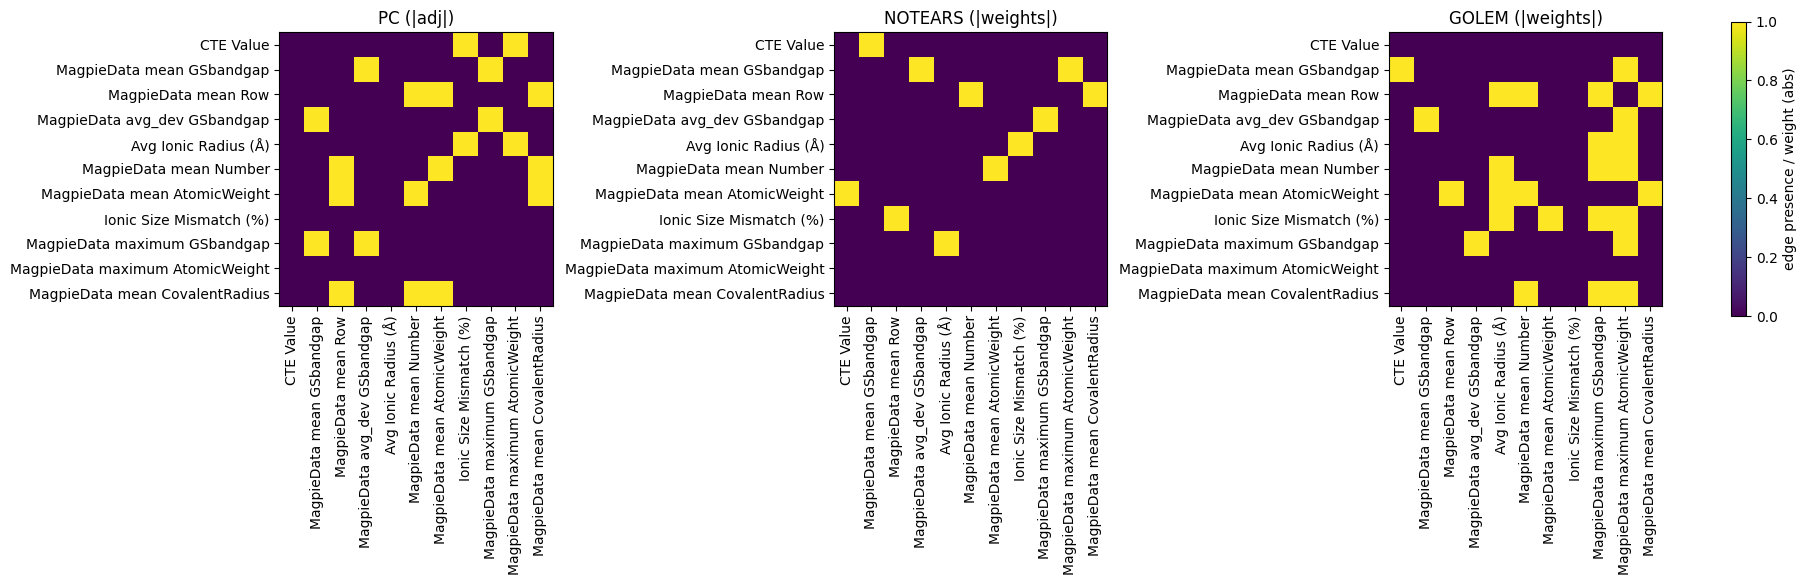

Direct parents of target under PC: []
Direct parents of target under NOTEARS: [('MagpieData mean AtomicWeight', 1.0)]
Direct parents of target under GOLEM: [('MagpieData mean GSbandgap', 1.0)]


In [25]:
from sklearn.preprocessing import StandardScaler

# gCastle algorithms
from castle.algorithms import PC, Notears, GOLEM

# ---------------- 1) Build analysis matrix from df_important ----------------
# Keep all numeric columns (incl. the target), drop non-numeric like 'composition'
candidate_targets = ["CTE Value", "CTE"]
available = set(df_important.columns)
target_name = next((c for c in candidate_targets if c in available), None)
assert target_name is not None, "Neither 'CTE Value' nor 'CTE' found in df_important."

data_num = df_important.select_dtypes(include=[np.number]).copy()
assert target_name in data_num.columns, (
    f"Target '{target_name}' is not numeric; cast it to float first."
)

# Optional: drop rows with any NA in used columns (simple, robust default)
data_num = data_num.dropna(axis=0).copy()

# Standardize (helps Fisher-Z CI test and linear-SEMs)
names = data_num.columns.tolist()
X = StandardScaler().fit_transform(data_num.values)

print(f"Variables ({len(names)}): {names}")
print(f"Matrix shape: {X.shape}")

# ---------------- 2) Learn graphs ----------------
# A[i, j] means edge: names[i] -> names[j]
pc = PC(variant="stable", ci_test="fisherz", alpha=0.01)
pc.learn(X)
A_pc = pc.causal_matrix.astype(float)  # 0/1

print("PC done")

nt = Notears()              # tune lambda1, max_iter if needed
nt.learn(X)
A_nt = nt.causal_matrix     # weighted

print("NoTEARS done")

golem = GOLEM()             # fast NOTEARS-style variant
golem.learn(X)
A_g = golem.causal_matrix   # weighted

print("GOLEM done")

# Put into DataFrames for readability / export
A_pc_df = pd.DataFrame(A_pc, index=names, columns=names)
A_nt_df = pd.DataFrame(A_nt, index=names, columns=names)
A_g_df  = pd.DataFrame(A_g,  index=names, columns=names)

print("PC adjacency (0/1):")
display(A_pc_df)
print("NOTEARS adjacency (weights):")
display(A_nt_df)
print("GOLEM adjacency (weights):")
display(A_g_df)

# ---------------- 3) Plot side-by-side heatmaps ----------------
mmax = max(1.0, np.abs(A_nt).max(), np.abs(A_g).max())  # PC is 0/1; scale to max weight

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

def heat(ax, A, title):
    im = ax.imshow(np.abs(A), vmin=0, vmax=mmax)
    ax.set_title(title)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=90)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
    return im

im0 = heat(axes[0], A_pc, "PC (|adj|)")
im1 = heat(axes[1], A_nt, "NOTEARS (|weights|)")
im2 = heat(axes[2], A_g,  "GOLEM (|weights|)")

# one shared colorbar
cbar = fig.colorbar(im2, ax=axes, shrink=0.8)
cbar.set_label("edge presence / weight (abs)")

plt.show()

# ---------------- 4) (Optional) direct parents of the target ----------------
def parents_of(target, A, names, thresh=1e-6):
    j = names.index(target)
    out = [(names[i], float(A[i, j])) for i in range(len(names)) if abs(A[i, j]) > thresh]
    return sorted(out, key=lambda t: abs(t[1]), reverse=True)

print("Direct parents of target under PC:", parents_of(target_name, A_pc, names, thresh=0.5)) # ~binary
print("Direct parents of target under NOTEARS:", parents_of(target_name, A_nt, names))
print("Direct parents of target under GOLEM:", parents_of(target_name, A_g, names))

# ---------------- 5) (Optional) save results ----------------
# A_pc_df.to_csv("adjacency_pc.csv")
# A_nt_df.to_csv("adjacency_notears.csv")
# A_g_df.to_csv("adjacency_golem.csv")


Interpreting NOTEARS Weights

**Short answer:** In NOTEARS, the entries of the learned adjacency matrix are **linear structural coefficients** of a **linear structural equation model (SEM)**. They are *not* probabilities.

---

The model NOTEARS fits

A linear SEM:
\[
\mathbf{x} = W^\top \mathbf{x} + \boldsymbol{\varepsilon},
\quad \text{with independent noise terms } \boldsymbol{\varepsilon},
\]
subject to an **acyclicity** constraint on the directed graph encoded by \(W\).

- If \(W_{ij} \neq 0\), then there is an edge \(j \rightarrow i\).
- The number \(W_{ij}\) is the **direct effect** of \(X_j\) on \(X_i\) (holding other parents of \(X_i\) fixed).

> **gCastle convention:** in `causal_matrix`, entry \(\text{A}[i,j]\) corresponds to edge **\(i \rightarrow j\)**. So **the parents of a target \(Y\)** are the **nonzero entries in the column for \(Y\)**.

---

How to read the weights

- **Magnitude \(|W_{ij}|\):** strength of the *direct* linear influence \(j \to i\).  
- **Sign:** positive/negative direction of effect.  
- **Scaling:** coefficients depend on variable scaling. If you **standardize** each variable (mean 0, var 1), weights become **standardized direct effects**, making magnitudes more comparable across edges.

---

Practical usage

- **Find direct causes of a target \(Y\):** look down the **column for \(Y\)** (using gCastle’s convention \(i \to j\)). Larger \(|W_{iY}|\) ⇒ stronger direct driver \(i \to Y\).
- **Threshold tiny weights:** Optimization + \(\ell_1\) sparsity often yields very small nonzeros. Use a small threshold (e.g., \(10^{-3}\)) or **bootstrap** for stability (keep edges that recur frequently).
- **Total vs. direct effects:** Along a path \(a \to b \to c\), the **path effect** is the **product** \(W_{ba}\cdot W_{cb}\). A **total effect** sums over all directed paths from cause to effect (interpretable when the DAG is causal).

---

Caveats

- **Modeling assumptions:** Causal interpretation needs (approximately) linear relations, independent noise, no substantial unobserved confounding, and correct edge orientations.
- **Scaling matters:** Compare magnitudes only after consistent preprocessing (e.g., standardization).
- **Regularization sensitivity:** Stronger sparsity penalties ⇒ fewer, smaller edges; tune and validate.

---


In [26]:
# GOLEM takes a while
# As aquick hack, I assume that it is equal to NoTEARS
#A_g = A_nt

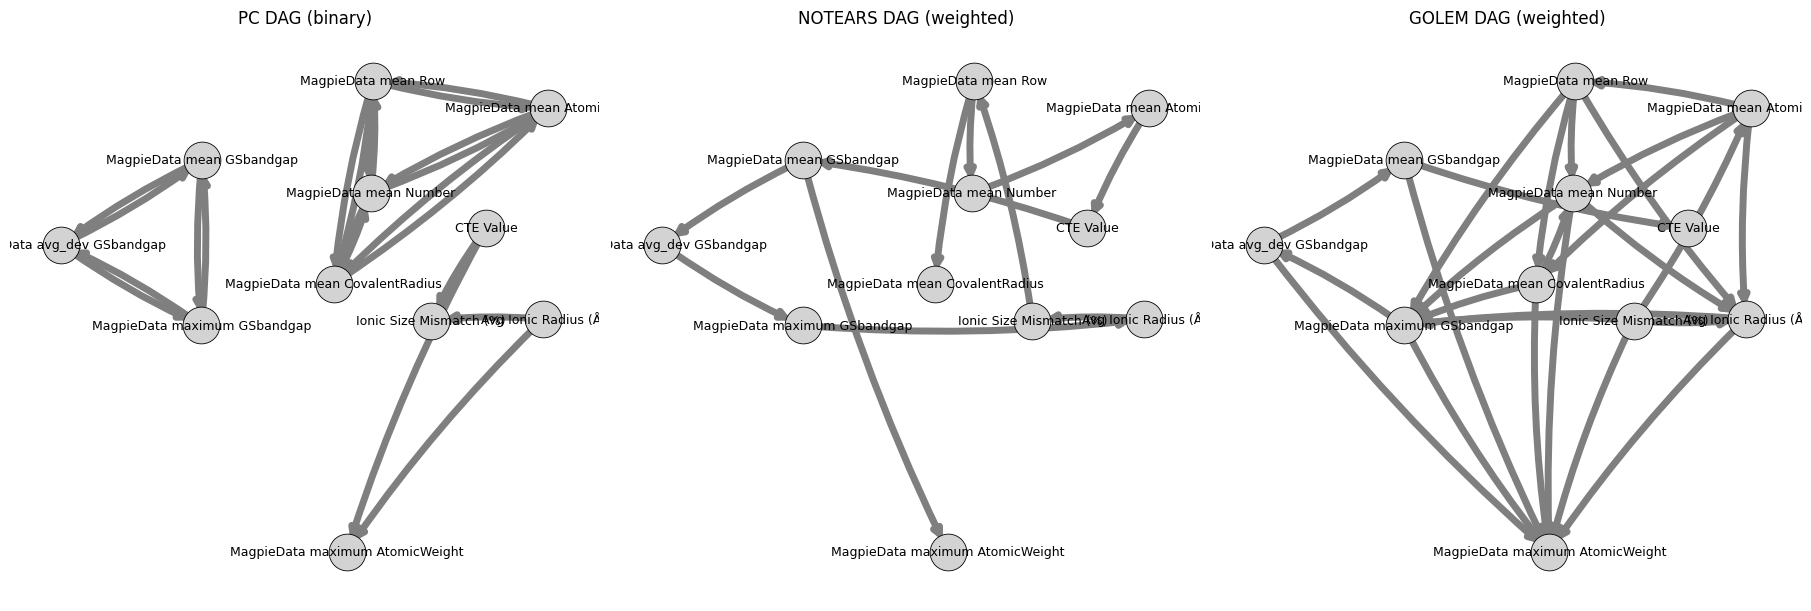

In [27]:
# --- installs if needed ---
# !pip install gcastle networkx matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import StandardScaler

def adj_to_digraph(A, names, thr=0.0, label="", binary=False):
    """
    Convert adjacency matrix A (A[i,j] = i -> j) to a NetworkX DiGraph.
    thr: absolute weight threshold; edges with |w| <= thr are dropped.
    binary: if True, treat edges as unweighted (e.g., PC).
    """
    G = nx.DiGraph(name=label)
    G.add_nodes_from(names)
    n = len(names)
    for i, u in enumerate(names):
        for j, v in enumerate(names):
            w = float(A[i, j])
            if abs(w) > thr:
                # For binary graphs (PC), set weight=1 and sign=+1
                if binary:
                    G.add_edge(u, v, weight=1.0, sign=1)
                else:
                    G.add_edge(u, v, weight=abs(w), sign=np.sign(w) if w != 0 else 1)
    return G

def draw_dag(ax, G, pos, title):
    # Edge styling: width ~ weight; color by sign (blue=+, red=-); binary will be gray
    if G.number_of_edges() == 0:
        nx.draw_networkx_nodes(G, pos, ax=ax, node_size=700, node_color="lightgray",
                               linewidths=0.6, edgecolors="k")
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)
        ax.set_title(title + " (no edges)")
        ax.axis("off")
        return

    weights = np.array([d["weight"] for *_ , d in G.edges(data=True)])
    wscale = 1 + 4 * (weights / (weights.max() if weights.max() > 0 else 1))

    # Edge colors
    colors = []
    for u, v, d in G.edges(data=True):
        if set(G.edges[u, v].keys()) and "sign" in d:
            if d["sign"] < 0:
                colors.append("tab:red")
            elif d["weight"] == 1.0 and all(d.get(k) is not None for k in ["weight","sign"]):
                # Heuristic: treat PC edges (binary) as gray
                colors.append("tab:gray")
            else:
                colors.append("tab:blue")
        else:
            colors.append("tab:blue")

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=700, node_color="lightgray",
                           linewidths=0.6, edgecolors="k")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=12,
                           width=wscale, edge_color=colors, connectionstyle="arc3,rad=0.05")
    ax.set_title(title)
    ax.axis("off")

# ---------------- build Graphs ----------------
# Thresholds: adjust if you want sparser/denser plots
thr_pc = 0.5      # PC adjacency is 0/1
thr_nt = 1e-3     # NOTEARS: drop tiny coefficients
thr_g  = 1e-3     # GOLEM: drop tiny coefficients

G_pc = adj_to_digraph(A_pc, names, thr=thr_pc, label="PC", binary=True)
G_nt = adj_to_digraph(A_nt, names, thr=thr_nt, label="NOTEARS", binary=False)
G_g  = adj_to_digraph(A_g,  names, thr=thr_g,  label="GOLEM",   binary=False)

# Consistent layout across all three: use union graph to compute positions once
G_union = nx.DiGraph()
G_union.add_nodes_from(names)
for G in (G_pc, G_nt, G_g):
    G_union.add_edges_from(G.edges())

pos = nx.spring_layout(G_union, seed=42)  # fixed for reproducibility

# ---------------- plot side-by-side ----------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
draw_dag(axes[0], G_pc, pos, "PC DAG (binary)")
draw_dag(axes[1], G_nt, pos, "NOTEARS DAG (weighted)")
draw_dag(axes[2], G_g,  pos, "GOLEM DAG (weighted)")
plt.show()


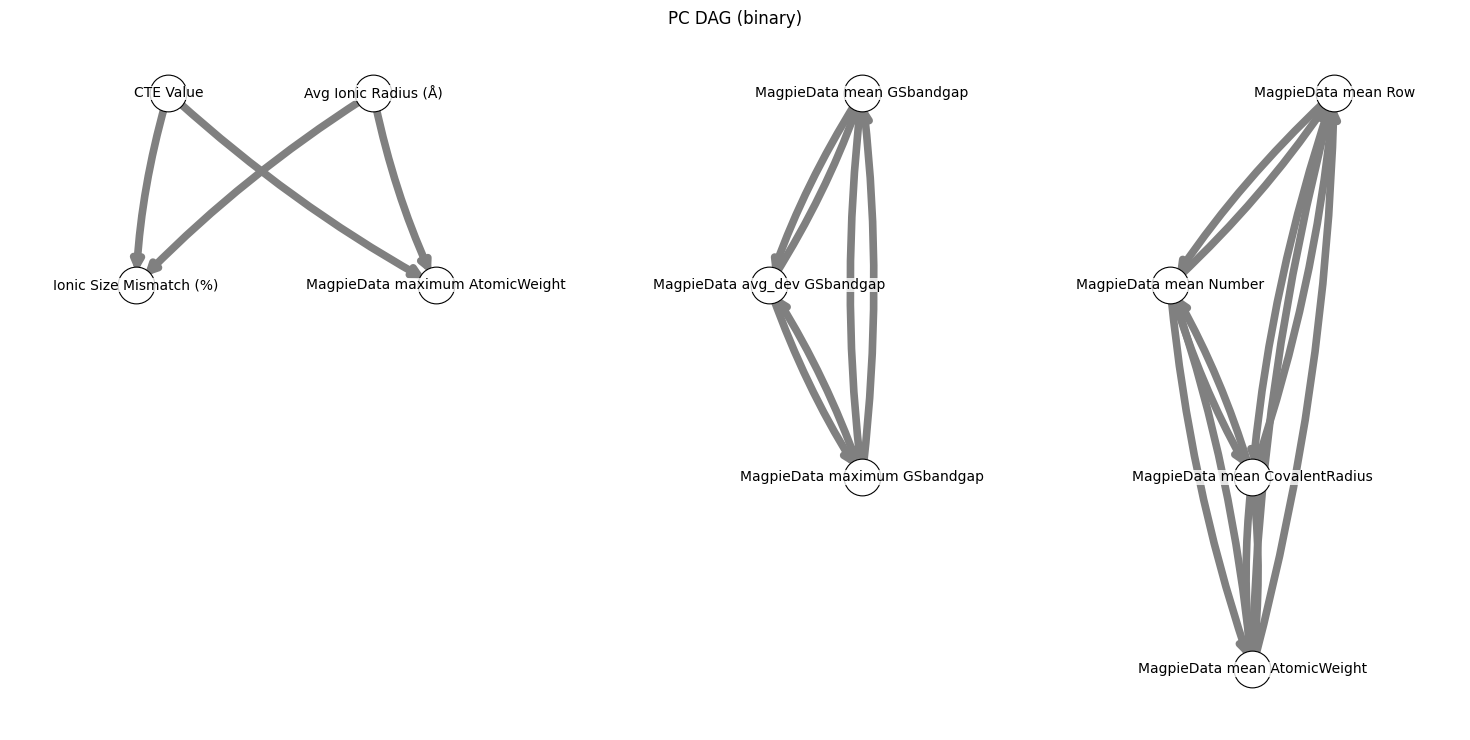

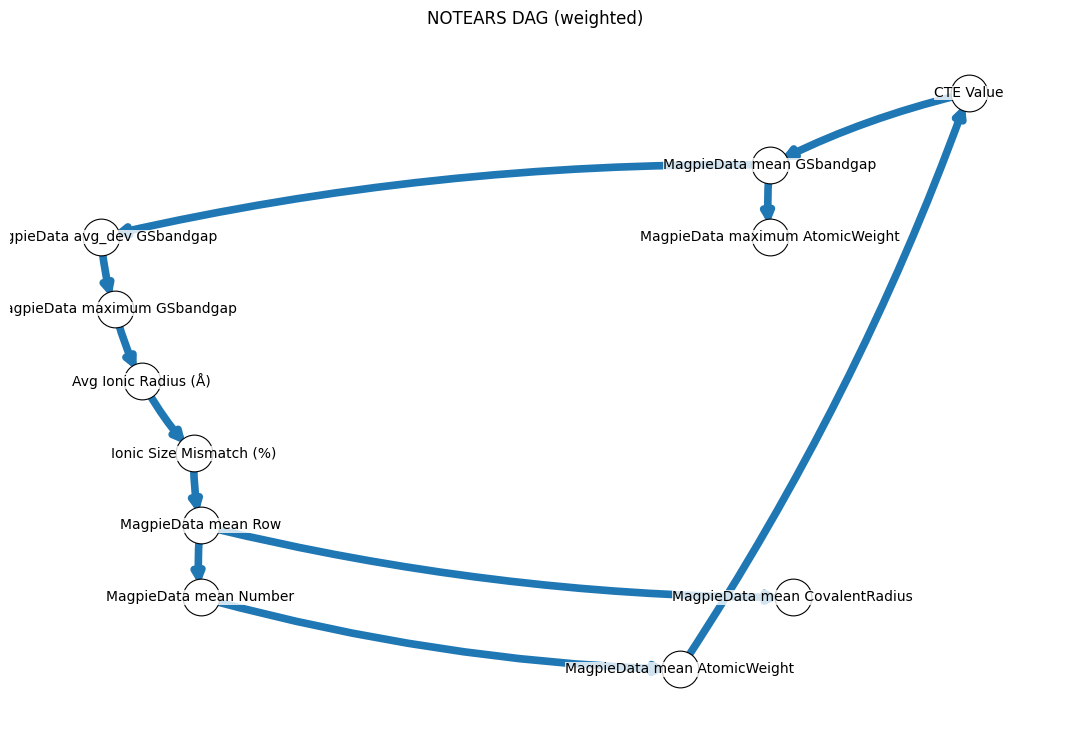

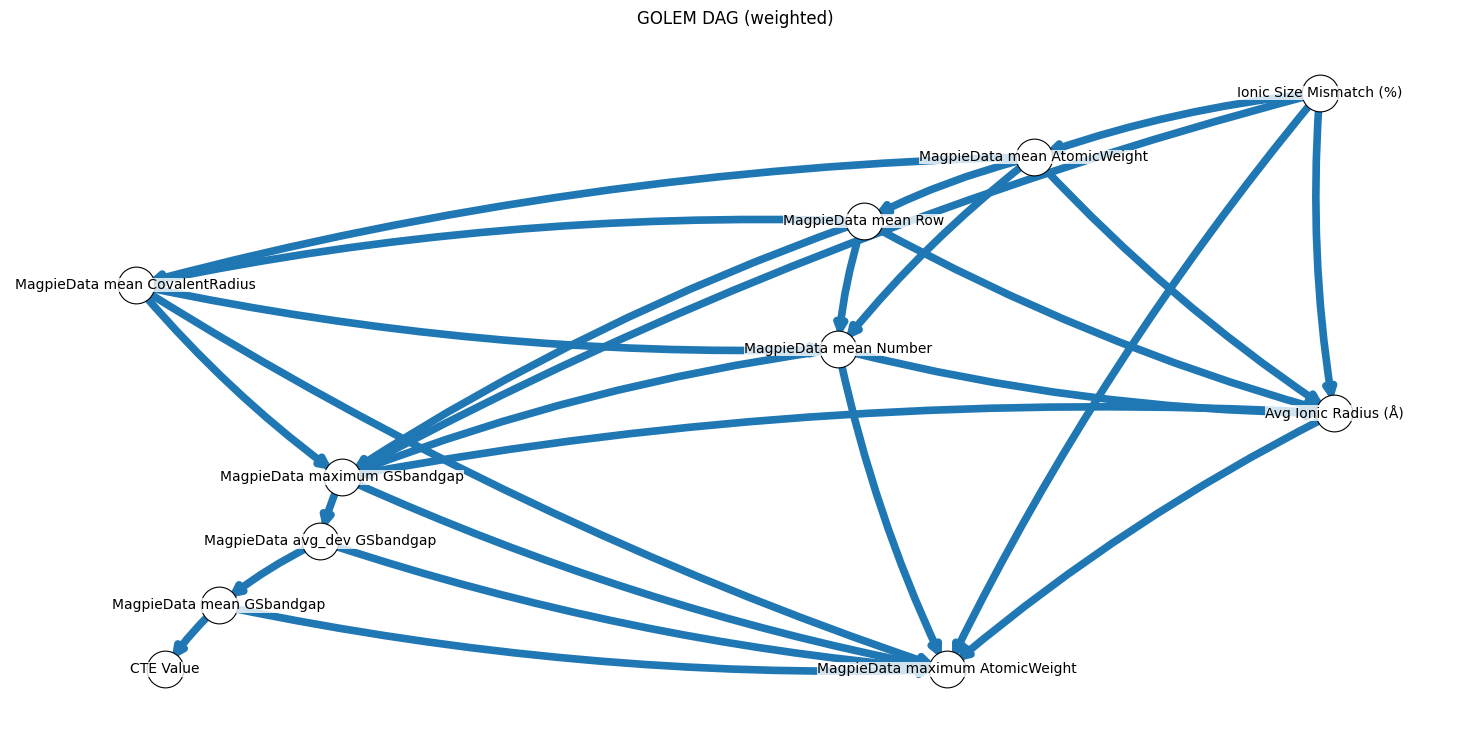

In [28]:
# --- installs (optional; uncomment in Colab if you want Graphviz-based layout) ---
# !apt-get -qq update && apt-get -qq install -y graphviz
# !pip install -q pygraphviz pydot

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# If you already have A_pc, A_nt, A_g, and names in memory, this will just plot them.
# Otherwise, define those first (from your gCastle run).

# ---------------- helpers ----------------
def adj_to_digraph(A, names, thr=0.0, binary=False):
    """
    A[i,j] = i -> j. Keep edges with |w| > thr.
    If binary=True (e.g., PC), edges are unweighted (weight=1).
    """
    G = nx.DiGraph()
    G.add_nodes_from(names)
    A = np.asarray(A, dtype=float)
    n = len(names)
    for i, u in enumerate(names):
        for j, v in enumerate(names):
            w = float(A[i, j])
            if abs(w) > thr:
                if binary:
                    G.add_edge(u, v, weight=1.0, sign=1)
                else:
                    G.add_edge(u, v, weight=abs(w), sign=np.sign(w) if w != 0 else 1)
    return G

def best_layout(G, prefer_prog="dot"):
    """
    Try high-quality Graphviz layouts first; fallback to Kamada-Kawai.
    Returns dict: node -> (x,y)
    """
    pos = None
    # Try pygraphviz
    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        pos = graphviz_layout(G, prog=prefer_prog, args='-Grankdir=LR')
    except Exception:
        # Try pydot
        try:
            from networkx.drawing.nx_pydot import graphviz_layout
            pos = graphviz_layout(G, prog=prefer_prog)
        except Exception:
            pass
    if pos is None:
        # Fall back to a force-directed layout tuned to reduce overlap
        pos = nx.kamada_kawai_layout(G, weight=None)
    return pos

def fig_size_for_graph(G, min_w=6, min_h=4, max_w=24, max_h=18):
    """
    Heuristic figure size based on node/edge counts.
    """
    n = max(G.number_of_nodes(), 1)
    e = G.number_of_edges()
    w = np.clip(0.8 * n + 2, min_w, max_w)
    h = np.clip(0.5 * n + 2, min_h, max_h)
    # If dense, give more width
    if e > n*(n-1)/6:
        w = min(max_w, w + 4)
    return (w, h)

def draw_dag_single(A, names, title, thr=1e-3, binary=False, savepath=None):
    G = adj_to_digraph(A, names, thr=thr, binary=binary)
    pos = best_layout(G, prefer_prog="dot")

    # Build figure sized to content
    figsize = fig_size_for_graph(G)
    plt.figure(figsize=figsize)

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_size=700,
        node_color="white",
        edgecolors="black",
        linewidths=0.8
    )

    # Labels with white background to avoid clutter
    nx.draw_networkx_labels(
        G, pos,
        font_size=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.2)
    )

    # Edges
    if G.number_of_edges() > 0:
        weights = np.array([d["weight"] for *_ , d in G.edges(data=True)])
        # Edge width scale (cap to keep lines readable)
        width = 1.5 + 4.0 * (weights / (weights.max() if weights.max() > 0 else 1.0))

        # Colors by sign (gray for binary PC)
        colors = []
        for u, v, d in G.edges(data=True):
            if binary:
                colors.append("gray")
            else:
                colors.append("tab:red" if d.get("sign", 1) < 0 else "tab:blue")

        nx.draw_networkx_edges(
            G, pos,
            arrows=True, arrowstyle="-|>", arrowsize=14,
            width=width, edge_color=colors, connectionstyle="arc3,rad=0.06"
        )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()

# ---------------- thresholds (tune if needed) ----------------
thr_pc = 0.5     # PC is 0/1; 0.5 keeps edges == 1
thr_nt = 1e-3    # NOTEARS weights: drop tiny coefficients
thr_g  = 1e-3    # GOLEM weights: drop tiny coefficients

# ---------------- PLOT: three separate figures ----------------
draw_dag_single(A_pc, names, "PC DAG (binary)", thr=thr_pc, binary=True,  savepath=None)
draw_dag_single(A_nt, names, "NOTEARS DAG (weighted)", thr=thr_nt, binary=False, savepath=None)
draw_dag_single(A_g,  names, "GOLEM DAG (weighted)",  thr=thr_g,  binary=False, savepath=None)


## GEMINI LLM analysis

- Now, let's explore the physicist common sense via Gemini LLM
- Note that you have to add your own key!

In [29]:
!pip install -q google-generativeai tqdm

In [30]:
# Upgrade the SDK (run once per runtime)
# !pip install -U google-generativeai

import os, google.generativeai as genai

# Set your key (or set it in a previous cell/environment)
# os.environ["GOOGLE_API_KEY"] = "YOUR_KEY_HERE"

genai.configure(api_key='')

# List all models
all_models = list(genai.list_models())
print(f"Found {len(all_models)} models.\n")

# Show a compact table: model name + supported methods
for m in all_models:
    methods = ",".join(getattr(m, "supported_generation_methods", []))
    print(f"{m.name:40s}  {methods}")

# Filter to models that support generateContent (what you need)
gc_models = [m.name for m in all_models
             if "generateContent" in getattr(m, "supported_generation_methods", [])]
print("\nModels that support generateContent:")
for name in gc_models:
    print(" -", name)


Found 66 models.

models/embedding-gecko-001                embedText,countTextTokens
models/gemini-2.5-pro-preview-03-25       generateContent,countTokens,createCachedContent,batchGenerateContent
models/gemini-2.5-flash-preview-05-20     generateContent,countTokens,createCachedContent,batchGenerateContent
models/gemini-2.5-flash                   generateContent,countTokens,createCachedContent,batchGenerateContent
models/gemini-2.5-flash-lite-preview-06-17  generateContent,countTokens,createCachedContent,batchGenerateContent
models/gemini-2.5-pro-preview-05-06       generateContent,countTokens,createCachedContent,batchGenerateContent
models/gemini-2.5-pro-preview-06-05       generateContent,countTokens,createCachedContent,batchGenerateContent
models/gemini-2.5-pro                     generateContent,countTokens,createCachedContent,batchGenerateContent
models/gemini-2.0-flash-exp               generateContent,countTokens,bidiGenerateContent
models/gemini-2.0-flash                   gen

In [31]:
import os, re, json, time
from tqdm import tqdm
import google.generativeai as genai

genai.configure(api_key='')

# Pick a model (flash = cheaper/faster, pro = stronger)
MODEL_NAME = "models/gemini-2.5-flash"  # or "gemini-1.5-pro"
model = genai.GenerativeModel(MODEL_NAME)

In [32]:
import json, re

def causal_pair(model, A_name, A_desc, B_name, B_desc):
    prompt = f"""
You are a careful physicist. Decide the plausible DIRECT CAUSAL direction between two material-related variables using physics/common sense ONLY.
Return STRICT JSON: {{"label": one of [1,-1,0], "reason": "<=30 words"}}.
For ordered pair (A,B): 1=A→B, -1=B→A, 0=unknown/ambiguous.

A = "{A_name}" — {A_desc or "(no desc)"}
B = "{B_name}" — {B_desc or "(no desc)"}

Answer ONLY with the JSON.
"""
    resp = model.generate_content(prompt)
    text = (resp.text or "").strip()
    try:
        obj = json.loads(text)
    except Exception:
        m = re.search(r"\{.*\}", text, flags=re.S)
        obj = json.loads(m.group(0)) if m else {"label": 0, "reason": "no_response"}
    label = int(obj.get("label", 0))
    if label not in (-1, 0, 1):
        label = 0
    reason = str(obj.get("reason", "")).strip()
    return label, reason

# ---- Example usage (replace with your variables) ----
A_name = "MagpieData avg_dev GSbandgap"
A_desc = "Average deviation of elemental band gaps (composition heterogeneity)."
B_name = "Avg Ionic Radius (Å)"
B_desc = "Average ionic radius of species in composition (Å)."

label, reason = causal_pair(model, A_name, A_desc, B_name, B_desc)
print(f"Label: {label}  (1: A→B, -1: B→A, 0: unknown)")
print("Reason:", reason)


Label: 0  (1: A→B, -1: B→A, 0: unknown)
Reason: Both average ionic radius and average deviation of elemental band gaps are intrinsic descriptors derived from the material's elemental composition; one does not directly cause the other.


We generate the list of physics-aware descriptors for the causal analysis using ChatGPT

In [33]:
# Physics-aware descriptions for your Gemini prompting

var_info = {
    "MagpieData mean GSbandgap": "Mean elemental ground-state band gap of constituents (eV).",
    "MagpieData mean Row": "Mean periodic table row (principal shell index) of elements.",
    "MagpieData avg_dev GSbandgap": "Average deviation of elemental band gaps (composition heterogeneity).",
    "Avg Ionic Radius (Å)": "Average ionic radius of species in composition (Å).",
    "MagpieData mean Number": "Mean atomic number Z of constituent elements.",
    "MagpieData mean AtomicWeight": "Mean atomic mass of constituent elements (amu).",
    "Ionic Size Mismatch (%)": "Percent mismatch among ionic radii (size disparity).",
    "MagpieData maximum GSbandgap": "Maximum elemental ground-state band gap present (eV).",
    "MagpieData maximum AtomicWeight": "Maximum elemental atomic mass present (amu).",
    "MagpieData mean CovalentRadius": "Mean covalent radius of constituent elements (Å).",
}

In [34]:
var_names = list(var_info.keys())
print(f"{len(var_names)} variables:\n", var_names)

10 variables:
 ['MagpieData mean GSbandgap', 'MagpieData mean Row', 'MagpieData avg_dev GSbandgap', 'Avg Ionic Radius (Å)', 'MagpieData mean Number', 'MagpieData mean AtomicWeight', 'Ionic Size Mismatch (%)', 'MagpieData maximum GSbandgap', 'MagpieData maximum AtomicWeight', 'MagpieData mean CovalentRadius']


In [35]:
# ===========================================================
# 2) Build a strict pairwise prompt & a safe JSON parser
# ===========================================================
SYSTEM_INSTRUCTIONS = """\
You are a careful physicist. Decide plausible CAUSAL direction between two material-related variables
based on physics/common sense ONLY. Output strictly a JSON object with keys:
  "label": one of [1, -1, 0],
  "reason": short string (<= 30 words).
Interpretation of label for an ordered pair (A,B):
  1  => A causes B (A → B)
 -1  => B causes A (B → A)
  0  => unknown/ambiguous/no direct causal direction

Make you best guess about causal directions, avoid being unsure
"""

PAIR_TEMPLATE = """\
Variables:
- A = "{ai}" — {ad}
- B = "{bj}" — {bd}

Task: Using physics common sense (no data), is there a plausible direct causal relation?
Respond as compact JSON, e.g. {{"label":1,"reason":"..."}} with NO extra text.
"""

def ask_gemini_for_pair(ai, aj, adesc, bdesc, max_retries=3, sleep=1.2):
    prompt = SYSTEM_INSTRUCTIONS + "\n" + PAIR_TEMPLATE.format(ai=ai, ad=adesc or "(no desc)",
                                                              bj=aj, bd=bdesc or "(no desc)")
    for _ in range(max_retries):
        try:
            resp = model.generate_content(prompt)
            print(prompt)
            text = resp.text.strip()
            # Try JSON parsing directly
            try:
                obj = json.loads(text)
            except Exception:
                # Fallback: extract {...} block with a regex and parse again
                m = re.search(r"\{.*\}", text, flags=re.S)
                obj = json.loads(m.group(0)) if m else {}
            label = int(obj.get("label", 0))
            if label not in (-1, 0, 1):
                label = 0
            reason = str(obj.get("reason", "")).strip()
            return label, reason
        except Exception:
            time.sleep(sleep)
    # If all retries fail:
    return 0, "no_response"


In [36]:
SYSTEM_INSTRUCTIONS

'You are a careful physicist. Decide plausible CAUSAL direction between two material-related variables\nbased on physics/common sense ONLY. Output strictly a JSON object with keys:\n  "label": one of [1, -1, 0],\n  "reason": short string (<= 30 words).\nInterpretation of label for an ordered pair (A,B):\n  1  => A causes B (A → B)\n -1  => B causes A (B → A)\n  0  => unknown/ambiguous/no direct causal direction\n\nMake you best guess about causal directions, avoid being unsure\n'

Now let's run Gemini analysis. This can be time consuming and expensive, since we query each pair. That's why we use only variables that have been determined to be significant according to SHAP.

In [37]:
# ===========================================================
# 3) Query all unordered pairs and assemble an adjacency
#    A[i,j] = +1 (i→j), -1 (j→i), 0 (unknown); enforce skew-symmetry
# ===========================================================

n = len(var_names)
A = np.zeros((n, n), dtype=int)
reasons = {}  # (i,j) -> reason for i<j

pairs = [(i, j) for i in range(n) for j in range(i+1, n)]

for i, j in tqdm(pairs, desc="Gemini causal pairs"):
    ai, aj = var_names[i], var_names[j]
    ad, bd = var_info[ai], var_info[aj]
    label, reason = ask_gemini_for_pair(ai, aj, ad, bd)
    # Enforce antisymmetry
    if label == 1:       # i -> j
        A[i, j] = 1;  A[j, i] = -1
    elif label == -1:    # j -> i
        A[i, j] = -1; A[j, i] = 1
    else:                # unknown
        A[i, j] = 0;  A[j, i] = 0
    reasons[(i, j)] = reason

adj_df = pd.DataFrame(A, index=var_names, columns=var_names)
adj_df.head()

Gemini causal pairs:   2%|▏         | 1/45 [00:05<04:03,  5.54s/it]

You are a careful physicist. Decide plausible CAUSAL direction between two material-related variables
based on physics/common sense ONLY. Output strictly a JSON object with keys:
  "label": one of [1, -1, 0],
  "reason": short string (<= 30 words).
Interpretation of label for an ordered pair (A,B):
  1  => A causes B (A → B)
 -1  => B causes A (B → A)
  0  => unknown/ambiguous/no direct causal direction

Make you best guess about causal directions, avoid being unsure

Variables:
- A = "MagpieData mean GSbandgap" — Mean elemental ground-state band gap of constituents (eV).
- B = "MagpieData mean Row" — Mean periodic table row (principal shell index) of elements.

Task: Using physics common sense (no data), is there a plausible direct causal relation?
Respond as compact JSON, e.g. {"label":1,"reason":"..."} with NO extra text.



Gemini causal pairs:   4%|▍         | 2/45 [00:15<05:45,  8.03s/it]

You are a careful physicist. Decide plausible CAUSAL direction between two material-related variables
based on physics/common sense ONLY. Output strictly a JSON object with keys:
  "label": one of [1, -1, 0],
  "reason": short string (<= 30 words).
Interpretation of label for an ordered pair (A,B):
  1  => A causes B (A → B)
 -1  => B causes A (B → A)
  0  => unknown/ambiguous/no direct causal direction

Make you best guess about causal directions, avoid being unsure

Variables:
- A = "MagpieData mean GSbandgap" — Mean elemental ground-state band gap of constituents (eV).
- B = "MagpieData avg_dev GSbandgap" — Average deviation of elemental band gaps (composition heterogeneity).

Task: Using physics common sense (no data), is there a plausible direct causal relation?
Respond as compact JSON, e.g. {"label":1,"reason":"..."} with NO extra text.



Gemini causal pairs:   7%|▋         | 3/45 [00:24<06:02,  8.62s/it]

...

Gemini causal pairs:  98%|█████████▊| 44/45 [10:24<00:16, 16.92s/it]

You are a careful physicist. Decide plausible CAUSAL direction between two material-related variables
based on physics/common sense ONLY. Output strictly a JSON object with keys:
  "label": one of [1, -1, 0],
  "reason": short string (<= 30 words).
Interpretation of label for an ordered pair (A,B):
  1  => A causes B (A → B)
 -1  => B causes A (B → A)
  0  => unknown/ambiguous/no direct causal direction

Make you best guess about causal directions, avoid being unsure

Variables:
- A = "MagpieData maximum GSbandgap" — Maximum elemental ground-state band gap present (eV).
- B = "MagpieData mean CovalentRadius" — Mean covalent radius of constituent elements (Å).

Task: Using physics common sense (no data), is there a plausible direct causal relation?
Respond as compact JSON, e.g. {"label":1,"reason":"..."} with NO extra text.



Gemini causal pairs: 100%|██████████| 45/45 [10:52<00:00, 14.51s/it]

You are a careful physicist. Decide plausible CAUSAL direction between two material-related variables
based on physics/common sense ONLY. Output strictly a JSON object with keys:
  "label": one of [1, -1, 0],
  "reason": short string (<= 30 words).
Interpretation of label for an ordered pair (A,B):
  1  => A causes B (A → B)
 -1  => B causes A (B → A)
  0  => unknown/ambiguous/no direct causal direction

Make you best guess about causal directions, avoid being unsure

Variables:
- A = "MagpieData maximum AtomicWeight" — Maximum elemental atomic mass present (amu).
- B = "MagpieData mean CovalentRadius" — Mean covalent radius of constituent elements (Å).

Task: Using physics common sense (no data), is there a plausible direct causal relation?
Respond as compact JSON, e.g. {"label":1,"reason":"..."} with NO extra text.



,MagpieData mean GSbandgap,MagpieData mean Row,MagpieData avg_dev GSbandgap,Avg Ionic Radius (Å),MagpieData mean Number,MagpieData mean AtomicWeight,Ionic Size Mismatch (%),MagpieData maximum GSbandgap,MagpieData maximum AtomicWeight,MagpieData mean CovalentRadius
MagpieData mean GSbandgap,0,-1,0,-1,-1,-1,1,-1,-1,-1
MagpieData mean Row,1,0,1,1,-1,1,-1,1,1,1
MagpieData avg_dev GSbandgap,0,-1,0,0,-1,0,0,1,0,0
Avg Ionic Radius (Å),1,-1,0,0,-1,-1,0,0,-1,-1
MagpieData mean Number,1,1,1,1,0,1,1,1,-1,1


In [38]:
reason

'Heavier elements (high atomic weight) generally have more electron shells, leading to larger covalent radii, thus increasing the mean covalent radius.'

In [39]:
reasons

{(0,
  1): 'Higher periodic table row indicates larger atomic size and more diffuse valence orbitals, which generally leads to smaller band gaps or metallic character due to increased orbital overlap and weaker electron binding.',
 (0,
  2): 'Both variables are statistical descriptors (mean and average deviation) of the same set of elemental bandgaps; neither directly causes the other.',
 (0,
  3): 'Average ionic radius is a fundamental property influencing bond lengths, orbital overlap, and crystal structure, which collectively determine the electronic band gap.',
 (0,
  4): 'Mean atomic number (B) dictates the electronic configuration and atomic size of constituents, fundamentally influencing their electronic energy levels and thus the mean band gap (A). Band gap cannot alter atomic number.',
 (0,
  5): 'Mean atomic weight is a fundamental property related to atomic number and size, which influences electronic structure and bonding, thereby affecting the band gap. The reverse is phys

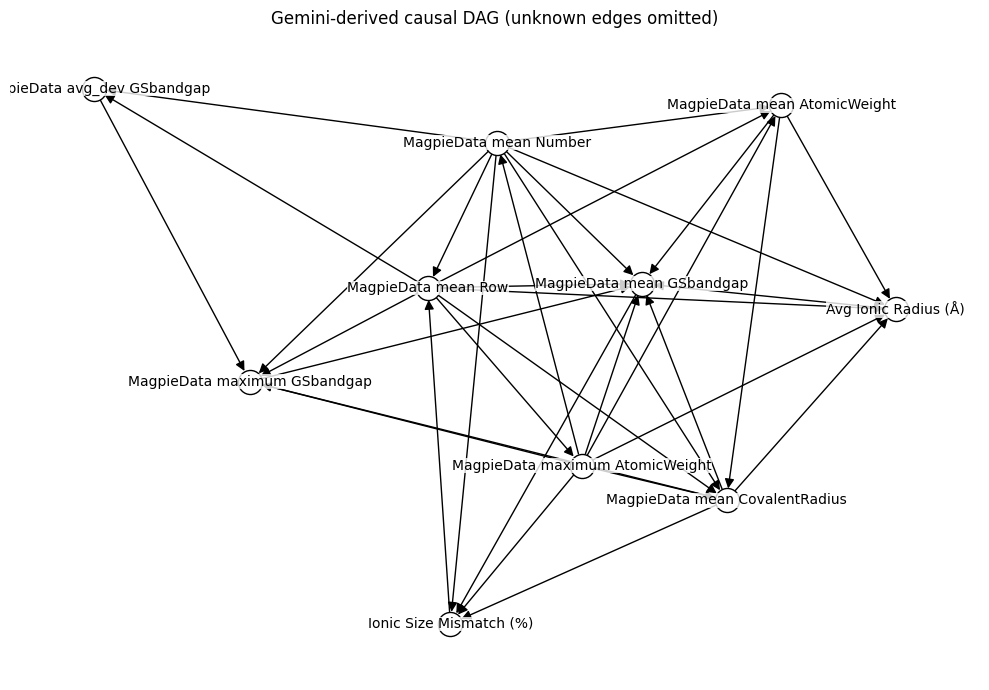

In [40]:
import networkx as nx

G = nx.DiGraph()
G.add_nodes_from(var_names)

for i in range(n):
    for j in range(n):
        if A[i, j] == 1:
            G.add_edge(var_names[i], var_names[j])

# Layout & draw
pos = nx.kamada_kawai_layout(G)
plt.figure(figsize=(max(8, 0.6*n + 4), max(6, 0.5*n + 2)))
nx.draw_networkx_nodes(G, pos, node_color="white", edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=10,
                        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.2))
if G.number_of_edges():
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=14)
plt.title("Gemini-derived causal DAG (unknown edges omitted)")
plt.axis("off"); plt.tight_layout(); plt.show()


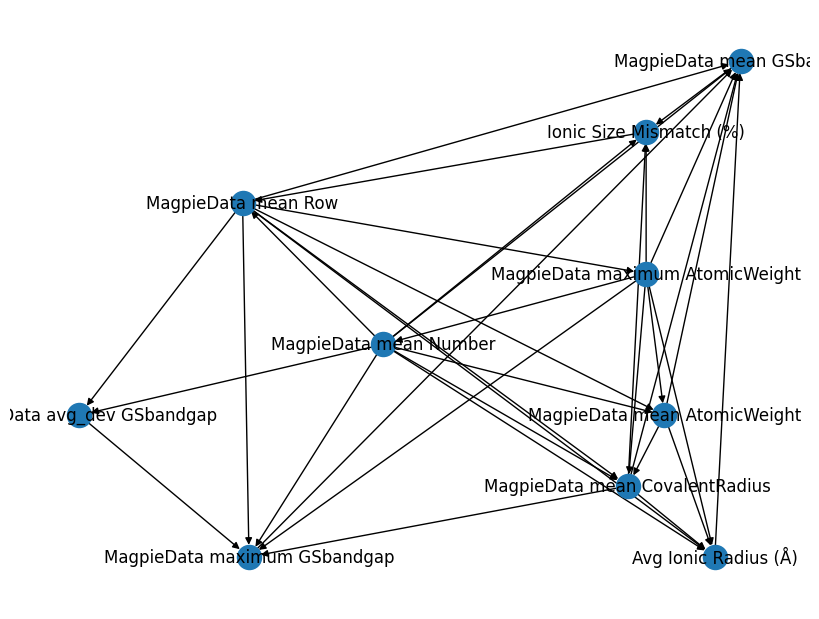

In [41]:
from networkx.drawing.nx_pydot import graphviz_layout
pos = graphviz_layout(G, prog="dot")  # layered layout
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, arrows=isinstance(G, nx.DiGraph))
plt.tight_layout()
plt.show()

# ChatGPT Analysis

This is analysis performed directly in ChatGPT

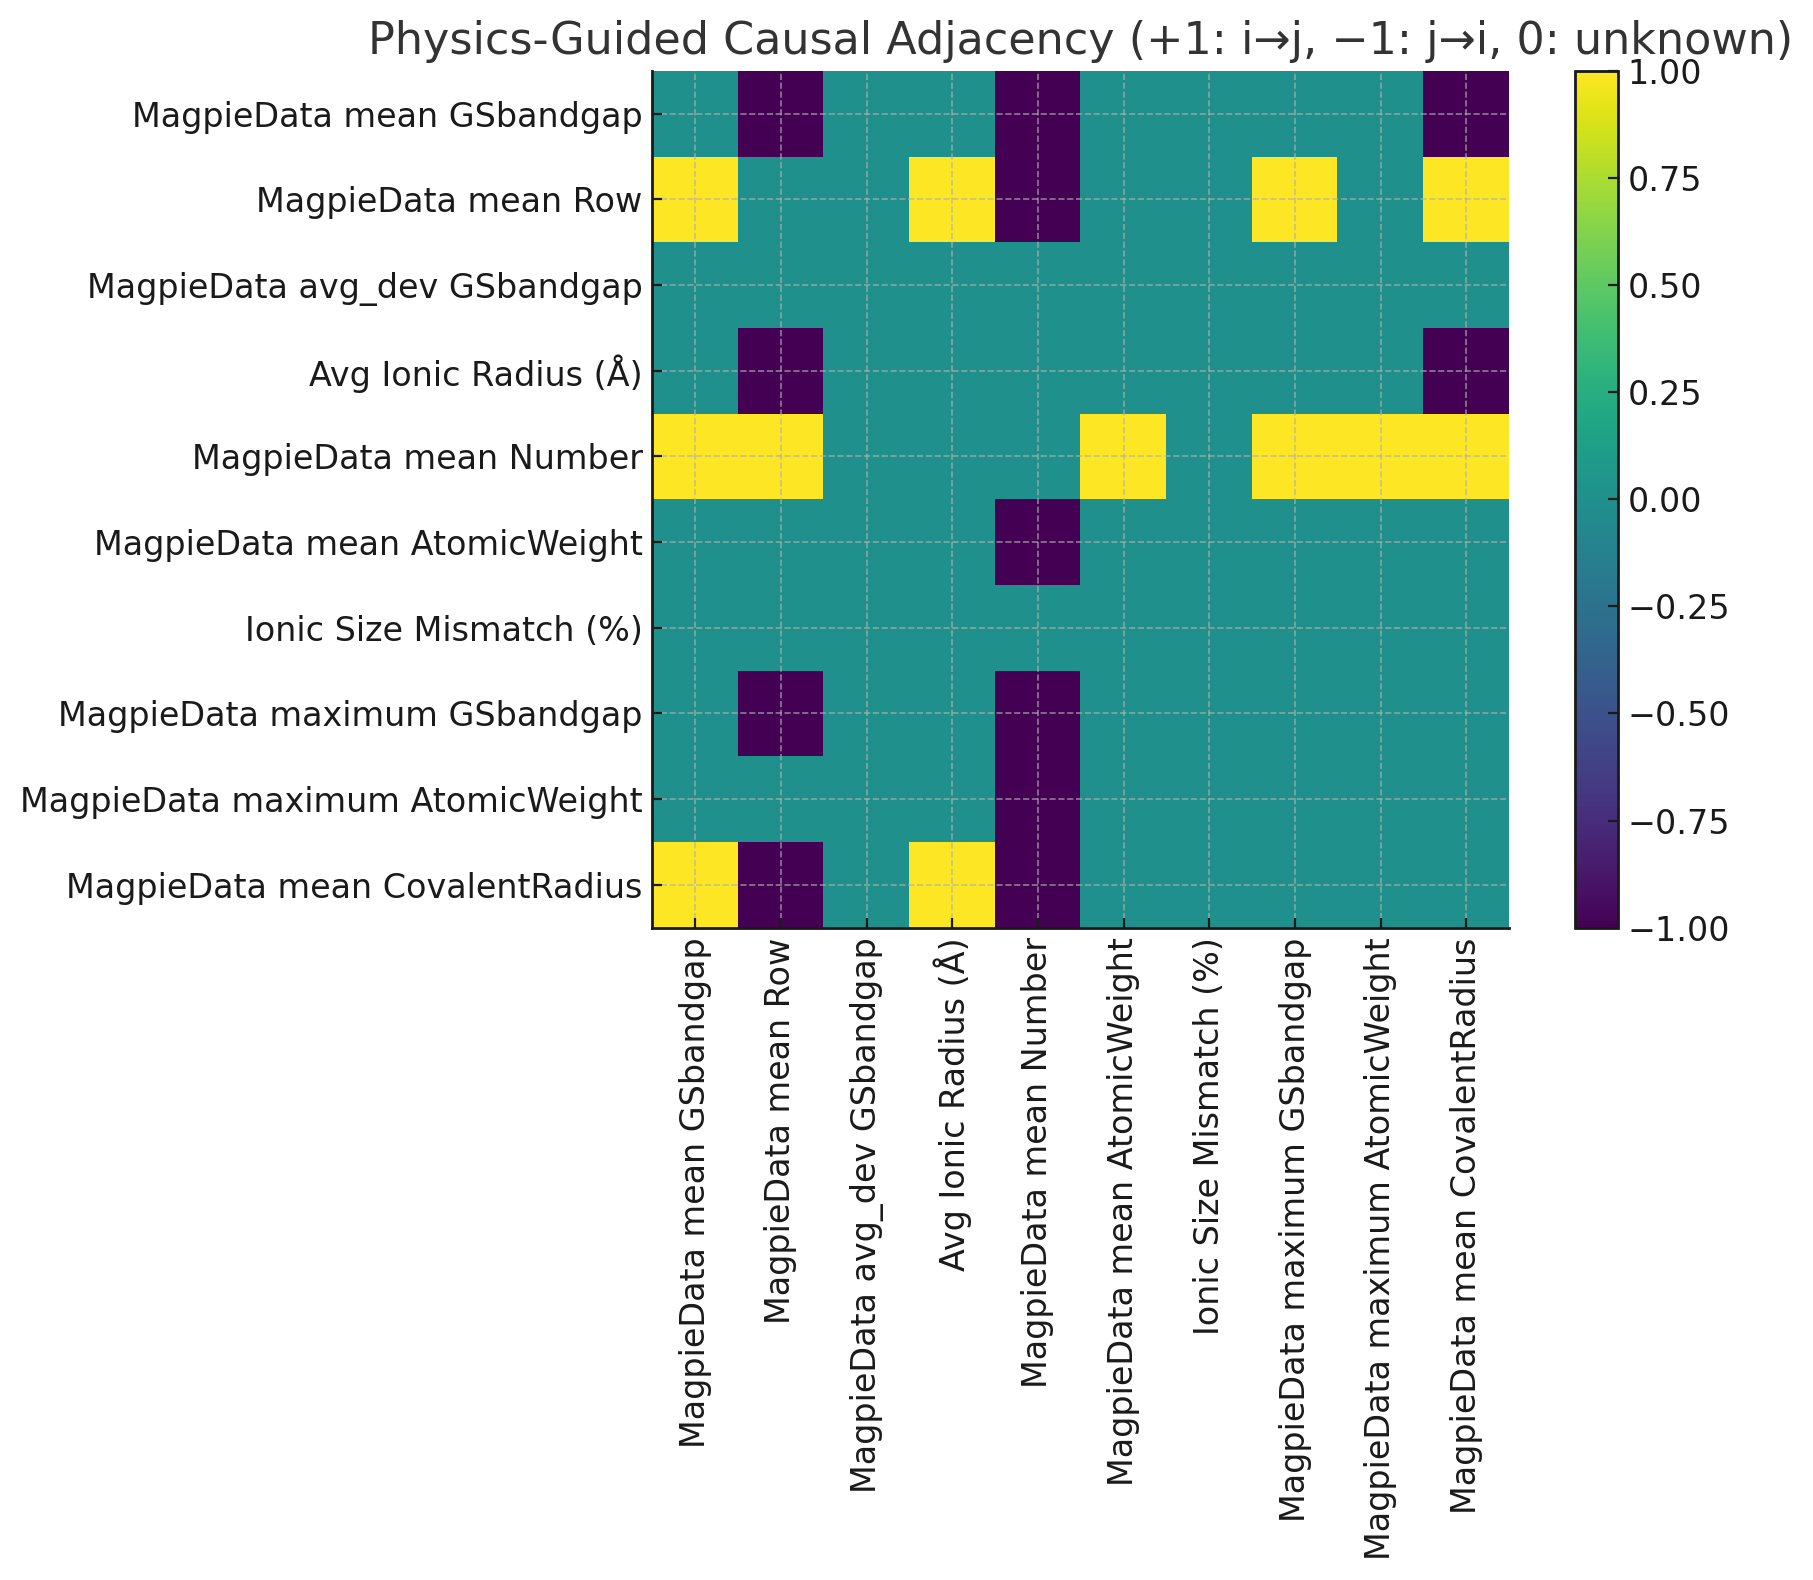

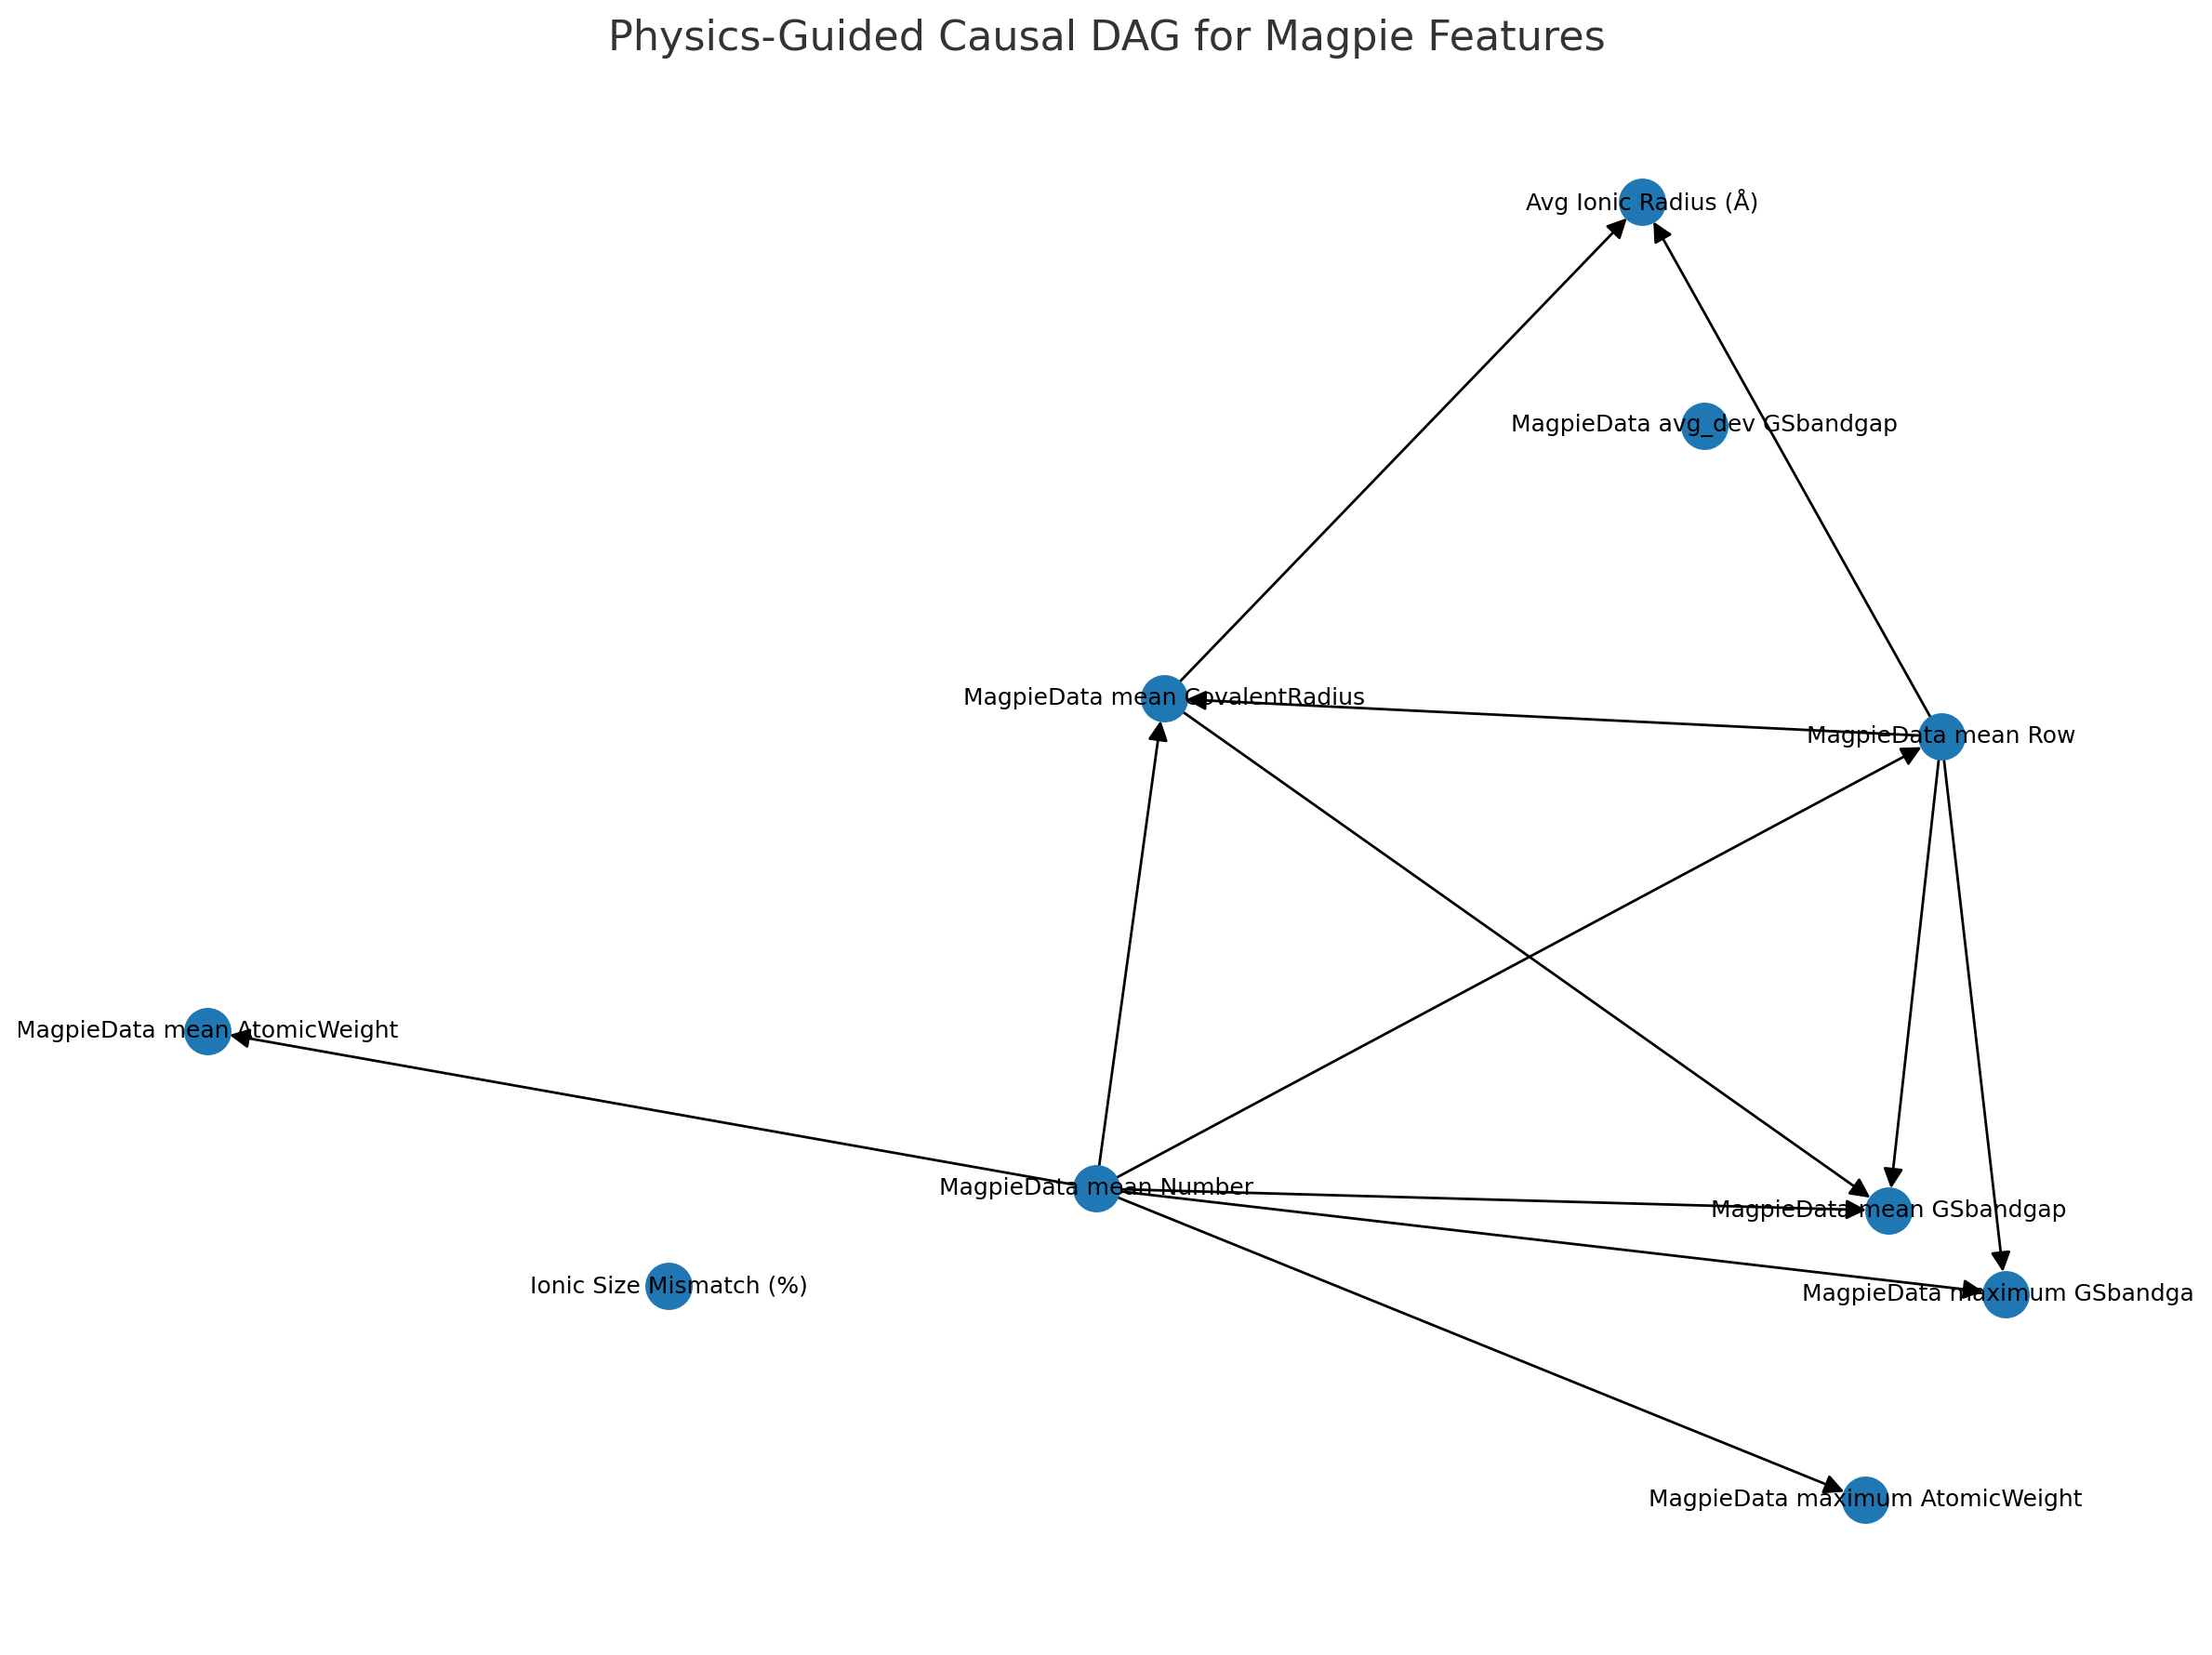